# 미션10
텍스트 데이터와 임베딩 토픽에서 배운 내용을 바탕으로 18,846개의 뉴스 문서를 20개의 카테고리로 분류한 News Group 20 데이터를 사용합니다.

텍스트 데이터를 입력으로 받아 뉴스의 카테고리를 예측하는 딥 러닝 모델을 구현합니다.

## 가이드라인
-**데이터 전처리**

    - 텍스트 데이터에서 토큰화를 수행하세요.

    - 데이터를 훈련 세트와 테스트 세트로 적절히 분리하세요.

-**임베딩 적용**

    - Word2Vec, FastText, GloVe 방식으로 입력 데이터를 벡터화하여 임베딩 행렬을 생성하세요.

-**데이터셋 및 로더 구현**

    - PyTorch의 Dataset과 DataLoader 객체를 활용해 데이터를 처리할 수 있도록 구현하세요.

    - 벡터화된 데이터를 모델에 입력 가능한 형태로 변환하세요.

-**모델 구현**

    - LSTM, GRU 등 RNN 기반의 딥 러닝 모델을 구현하세요.

    - 임베딩 레이어를 추가해 입력 데이터와 임베딩 벡터를 연결하세요.

    - 각 임베딩 방식(Word2Vec, FastText, GloVe)에 대해 모델을 학습할 수 있도록 설정하세요.

-**모델 학습 및 평가**

    - 모델을 학습시키고, 테스트 데이터에서 정확도 등 주요 평가지표를 계산하세요.

    - Word2Vec, FastText, GloVe 임베딩 방식을 사용했을 때의 성능을 비교하고 결과를 분석하세요.

-**모델 성능 개선(심화)**

    - 데이터 전처리(특수 문자, 불용어 제거 등) 및 모델 구조 변경, 하이퍼파라미터 튜닝 등을 통해 모델의 성능을 높여 나가 보세요.

---


토픽 모델링이 이 주제에 어울릴것 같아서 정의를 가지고 왔습니다.


#### 토픽 모델링

토픽 모델링은 문서들에 잠재되어 있는 공통된 토픽(주제)들을 추출해 내는 기법을 의미합니다.

공통된 유사성을 도출한다는 측면에서 문서 군집화/유사도와 비슷한 기법이나

토픽 모델링은 문서들이 가지는 주요 토픽의 분포도와 개별 토픽이 어떤 의미인지 (단어들의 분포)를 제공하는 특징을 가지고 있습니다.

In [1]:
"""
20 Newsgroups 데이터셋 직접 다운로드
"""
import os
import urllib.request
import tarfile

def download_20newsgroups():
    """20 newsgroups 데이터셋을 직접 다운로드"""
    
    urls = [
        "http://qwone.com/~jason/20Newsgroups/20news-bydate.tar.gz",
        "https://ndownloader.figshare.com/files/5975967"
    ]
    
    filename = "20news-bydate.tar.gz"
    extract_dir = "20newsgroups_data"
    
    # 이미 다운로드되어 있는지 확인
    if os.path.exists(extract_dir):
        print(f"✓ 데이터셋이 이미 존재합니다: {extract_dir}")
        return extract_dir
    
    # User-Agent 헤더 추가하여 다운로드
    for url in urls:
        try:
            print(f"다운로드 시도 중: {url}")
            
            req = urllib.request.Request(
                url,
                headers={'User-Agent': 'Mozilla/5.0'}
            )
            
            with urllib.request.urlopen(req, timeout=30) as response:
                total_size = response.headers.get('Content-Length')
                if total_size:
                    total_size = int(total_size)
                    print(f"파일 크기: {total_size / 1024 / 1024:.2f} MB")
                
                with open(filename, 'wb') as out_file:
                    chunk_size = 8192
                    downloaded = 0
                    while True:
                        chunk = response.read(chunk_size)
                        if not chunk:
                            break
                        out_file.write(chunk)
                        downloaded += len(chunk)
                        if total_size:
                            progress = (downloaded / total_size) * 100
                            print(f"\r진행률: {progress:.1f}%", end='', flush=True)
                    print()
            
            print("✓ 다운로드 완료!")
            break
            
        except Exception as e:
            print(f"✗ 다운로드 실패: {e}")
            if url == urls[-1]:
                print("\n모든 다운로드 URL이 실패했습니다.")
                print("수동으로 다운로드하세요:")
                print("http://qwone.com/~jason/20Newsgroups/20news-bydate.tar.gz")
                return None
    
    # 압축 해제
    print("\n압축 해제 중...")
    try:
        with tarfile.open(filename, 'r:gz') as tar:
            tar.extractall(extract_dir)
        print(f"✓ 압축 해제 완료: {extract_dir}")
        return extract_dir
    except Exception as e:
        print(f"✗ 압축 해제 실패: {e}")
        return None

# 다운로드 실행
download_20newsgroups()

다운로드 시도 중: http://qwone.com/~jason/20Newsgroups/20news-bydate.tar.gz
파일 크기: 13.79 MB
진행률: 100.0%
✓ 다운로드 완료!

압축 해제 중...
✓ 압축 해제 완료: 20newsgroups_data


'20newsgroups_data'

기존 다운로드를 받았다면 아래 셀부터 시작합니다.

In [1]:
"""
다운로드한 20 Newsgroups 데이터를 sklearn 형식으로 로드
"""
from sklearn.datasets import load_files
from sklearn.utils import Bunch
import numpy as np

def load_20newsgroups_manual(data_dir="20newsgroups_data", subset='all'):
    """직접 다운로드한 20 newsgroups 데이터를 로드"""
    
    train_path = os.path.join(data_dir, "20news-bydate-train")
    test_path = os.path.join(data_dir, "20news-bydate-test")
    
    if not os.path.exists(train_path) and not os.path.exists(test_path):
        raise FileNotFoundError(
            f"데이터를 찾을 수 없습니다: {data_dir}\n"
            f"먼저 download_20newsgroups() 함수를 실행하세요."
        )
    
    if subset == 'train':
        print(f"훈련 데이터 로딩 중: {train_path}")
        data = load_files(train_path, encoding='latin1', decode_error='ignore', random_state=42)
    
    elif subset == 'test':
        print(f"테스트 데이터 로딩 중: {test_path}")
        data = load_files(test_path, encoding='latin1', decode_error='ignore', random_state=42)
    
    elif subset == 'all':
        print(f"모든 데이터 로딩 중...")
        train_data = load_files(train_path, encoding='latin1', decode_error='ignore', random_state=42)
        test_data = load_files(test_path, encoding='latin1', decode_error='ignore', random_state=42)
        
        data = Bunch(
            data=np.concatenate([train_data.data, test_data.data]),
            filenames=np.concatenate([train_data.filenames, test_data.filenames]),
            target=np.concatenate([train_data.target, test_data.target]),
            target_names=train_data.target_names,
            DESCR="20 Newsgroups dataset (train + test)"
        )
    else:
        raise ValueError("subset은 'train', 'test', 'all' 중 하나여야 합니다.")
    
    print(f"✓ 로딩 완료!")
    print(f"  - 문서 수: {len(data.data)}")
    print(f"  - 카테고리 수: {len(data.target_names)}")
    
    return data

In [2]:
import os
# train 데이터를 확인하기 위해 결과(Bunch 객체)를 train_data 변수에 저장
sample_data = load_20newsgroups_manual(subset='train')

# train_data 에 무엇이 들어가있는지 확인해봅시다.
# .keys() 를 사용하면 어떤 정보들이 있는지 목록을 확인 할 수 있습니다.

print("종류(keys) :", sample_data.keys())

훈련 데이터 로딩 중: 20newsgroups_data\20news-bydate-train
✓ 로딩 완료!
  - 문서 수: 11314
  - 카테고리 수: 20
종류(keys) : dict_keys(['data', 'filenames', 'target_names', 'target', 'DESCR'])


In [3]:
# 뉴스의 텍스트 본문 출력
print('뉴스 본문\n')
print(sample_data.data[1])

뉴스 본문

From: andy@SAIL.Stanford.EDU (Andy Freeman)
Subject: Re: Catalog of Hard-to-Find PC Enhancements (Repost)
Organization: Computer Science Department,  Stanford University.
Lines: 33

>andy@SAIL.Stanford.EDU (Andy Freeman) writes:
>> >In article <C5ELME.4z4@unix.portal.com> jdoll@shell.portal.com (Joe Doll) wr
>> >>   "The Catalog of Personal Computing Tools for Engineers and Scien-
>> >>   tists" lists hardware cards and application software packages for 
>> >>   PC/XT/AT/PS/2 class machines.  Focus is on engineering and scien-
>> >>   tific applications of PCs, such as data acquisition/control, 
>> >>   design automation, and data analysis and presentation.  
>> >
>> >>   If you would like a free copy, reply with your (U. S. Postal) 
>> >>   mailing address.
>> 
>> Don't bother - it never comes.  It's a cheap trick for building a
>> mailing list to sell if my junk mail flow is any indication.
>> 
>> -andy sent his address months ago
>
>Perhaps we can get Portal to nuke this weas

`>>` 가 나오는 경우도 있어서 확인 해본 결과 `>>` 은 **이중 인용문** 이라고 합니다.

원글 내용 (인용 없음)

`>` 첫 번째 답글의 인용

`>>` 두 번째 답글 인용 

`>>>` 세 번째 답글 인용

마크다운에서 `>` 는 > 로 표기가 됩니다.

In [4]:
import random

# 인용문이 있는 샘플 확인
print(f"="*60)
print(f">> (2단계 인용)이 포함된 랜덤 샘플 찾기")
print(f"="*60)

# 먼저 >> 가 있는 샘플들의 인덱스를 모두 수집
samples_with_double_quote = []
for i in range(len(sample_data.data)):
    if '>>' in sample_data.data[i]:
        samples_with_double_quote.append(i)

print(f"\n✓ 전체 {len(sample_data.data)}개 중 >> 인용문이 있는 샘플: {len(samples_with_double_quote)}개")

>> (2단계 인용)이 포함된 랜덤 샘플 찾기

✓ 전체 11314개 중 >> 인용문이 있는 샘플: 1750개


In [7]:
# 랜덤하게 1개 선택해서 보여주기
num_samples = min(1, len(samples_with_double_quote))
random_indices = random.sample(samples_with_double_quote, num_samples)

for idx in random_indices:
    text = sample_data.data[idx]
    print(f"\n" + "=" * 80)
    print(f"【샘플 {idx}】 카테고리: {sample_data.target_names[sample_data.target[idx]]}")
    print("=" * 80)
    print(text[:800])  # 처음 800자만 출력
    print("\n...(이하 생략)")
    
    # 인용문 레벨 분석 (문법 수정)
    lines = text.split('\n')
    single_quote = len([l for l in lines if l.strip().startswith('>') and not l.strip().startswith('>>')])
    double_quote = len([l for l in lines if l.strip().startswith('>>') and not l.strip().startswith('>>>')])
    triple_quote = len([l for l in lines if l.strip().startswith('>>>')])
    
    print(f"\n 인용문 통계:")
    print(f"   >    (1단계 인용): {single_quote}줄")
    print(f"   >>   (2단계 인용): {double_quote}줄")
    print(f"   >>>  (3단계 인용): {triple_quote}줄")


【샘플 895】 카테고리: comp.os.ms-windows.misc
From: tittle@ics.uci.edu (Cindy Tittle Moore)
Subject: Re: Canon BJ200 (BubbleJet) and HP DeskJet 500...
Nntp-Posting-Host: alexandre-dumas.ics.uci.edu
Reply-To: tittle@ics.uci.edu (Cindy Tittle Moore)
Organization: ICS Dept., UC Irvine
Keywords: printer
Lines: 25

In <~c$@byu.edu> ecktons@ucs.byu.edu (Sean Eckton) writes:

>>The deskjet is SLOW.  This is in comparison to the other printers I
>>mentioned.  I have no idea how the bubblejet compares.
>>
>>The interface between Win3.1 and the printer is just dandy, I've not
>>had any problems with it.

>I just bought a BJ-200 printer a couple of days ago.  I compared it to the
>sample print of an HP DeskJet 500 and knew that the HP wasn't for me.  The
>BJ-200 is pretty fast and really prints with good quality.  I can compare it
>with the HP L

...(이하 생략)

 인용문 통계:
   >    (1단계 인용): 7줄
   >>   (2단계 인용): 5줄
   >>>  (3단계 인용): 0줄


인용문은 다른사람이 쓴 글이기 때문에 모델 학습 시에는 삭제할 필요가 있습니다.

`header` (헤더 : 이메일의 '보낸 사람(From)', '받는 사람(To)', '제목(Subject)', '경로(Path)' 등과 같은 메타 정보)

`footers` (푸터 : 서명(signature)이나 소속 정보)

`quotes` (인용문)

을 제거하고 학습을 진행해야 함을 알 수 있습니다.

모델의 목표는 **순수하게 뉴스 기사의 '내용'을 보고 어떤 주제의 글인지를 맞추는 것**이기 때문입니다.

In [4]:
def remove_headers_footers_quotes(text):
    """텍스트에서 헤더, 푸터, 인용문 제거"""
    lines = text.split('\n')
    
    # 헤더 제거
    while lines and lines[0].strip():
        if ':' in lines[0]:
            lines.pop(0)
        else:
            break
    
    # 인용문 제거
    lines = [line for line in lines if not line.strip().startswith('>')]
    
    return '\n'.join(lines)


def load_20newsgroups_clean(data_dir="20newsgroups_data", subset='all', remove=None, preview=False):
    """
    Parameters:
    -----------
    data_dir : str
        데이터가 저장된 디렉토리
    subset : str
        'train', 'test', 'all' 중 하나
    remove : tuple or None
        제거할 항목 ('headers', 'footers', 'quotes')
    preview : bool
        True로 설정하면 데이터 구조를 먼저 보여줌 (키워드 이해를 위해)
    """
    
    data = load_20newsgroups_manual(data_dir, subset)

    if remove:
        if 'headers' in remove or 'footers' in remove or 'quotes' in remove:
            print("헤더, 푸터, 인용문 제거 중...")
            cleaned_data = []
            for text in data.data:
                cleaned_text = remove_headers_footers_quotes(text)
                cleaned_data.append(cleaned_text)
            data.data = cleaned_data
            print("✓ 정제 완료!")
    
    return data

데이터 로드 하기 전 Train 에는 remove 옵션을 적용하지만

test 에도 적용해야하는 의문이 들었습니다.

정답은 **둘 다 동일하게 처리** 해야합니다.

이유

1. **데이터 일관성**

2. **공정한 평가**

3. **실제 사용 환경**

In [5]:
# 데이터 로드
import os
news_data = load_20newsgroups_clean(
    data_dir="20newsgroups_data",
    subset='all',
    remove=('headers', 'footers', 'quotes')
)

print("\n=== 데이터 정보 ===")
print(f"전체 문서 수: {len(news_data.data)}")
print(f"카테고리 수: {len(news_data.target_names)}")
print(f"\n카테고리 목록:")
for i, name in enumerate(news_data.target_names):
    count = (news_data.target == i).sum()
    print(f"  {i:2d}. {name:30s} ({count:4d} 문서)")

모든 데이터 로딩 중...
✓ 로딩 완료!
  - 문서 수: 18846
  - 카테고리 수: 20
헤더, 푸터, 인용문 제거 중...
✓ 정제 완료!

=== 데이터 정보 ===
전체 문서 수: 18846
카테고리 수: 20

카테고리 목록:
   0. alt.atheism                    ( 799 문서)
   1. comp.graphics                  ( 973 문서)
   2. comp.os.ms-windows.misc        ( 985 문서)
   3. comp.sys.ibm.pc.hardware       ( 982 문서)
   4. comp.sys.mac.hardware          ( 963 문서)
   5. comp.windows.x                 ( 988 문서)
   6. misc.forsale                   ( 975 문서)
   7. rec.autos                      ( 990 문서)
   8. rec.motorcycles                ( 996 문서)
   9. rec.sport.baseball             ( 994 문서)
  10. rec.sport.hockey               ( 999 문서)
  11. sci.crypt                      ( 991 문서)
  12. sci.electronics                ( 984 문서)
  13. sci.med                        ( 990 문서)
  14. sci.space                      ( 987 문서)
  15. soc.religion.christian         ( 997 문서)
  16. talk.politics.guns             ( 910 문서)
  17. talk.politics.mideast          ( 940 문서)
  18. talk.politic

In [11]:
print(f"데이터 타입: {type(news_data)}")
print(f"속성: {news_data.keys()}")
print(f"\n샘플 데이터:")
print(f"첫 문서 길이: {len(news_data.data[0])} 문자")
print(f"첫 문서 타겟: {news_data.target[0]} ({news_data.target_names[news_data.target[0]]})")

데이터 타입: <class 'sklearn.utils._bunch.Bunch'>
속성: dict_keys(['data', 'filenames', 'target', 'target_names', 'DESCR'])

샘플 데이터:
첫 문서 길이: 1004 문자
첫 문서 타겟: 12 (sci.electronics)


news_data 의 속성에는 : `data`, `filenames`, `target`, `target_names`, `DESCR` 가 있습니다.

In [16]:
print(f'target :', news_data.target)
print(f'targetNames :', news_data.target_names)
print(f'DESCR', news_data.DESCR)

target : [12  6  9 ... 13  2 18]
targetNames : ['alt.atheism', 'comp.graphics', 'comp.os.ms-windows.misc', 'comp.sys.ibm.pc.hardware', 'comp.sys.mac.hardware', 'comp.windows.x', 'misc.forsale', 'rec.autos', 'rec.motorcycles', 'rec.sport.baseball', 'rec.sport.hockey', 'sci.crypt', 'sci.electronics', 'sci.med', 'sci.space', 'soc.religion.christian', 'talk.politics.guns', 'talk.politics.mideast', 'talk.politics.misc', 'talk.religion.misc']
DESCR 20 Newsgroups dataset (train + test)


`new_data.data` -> 전체 문서 (train + test)

`new_data.target` -> 전체 레이블

train 과 test 를 분리하겠습니다.

In [6]:
train_data = load_20newsgroups_clean(
    data_dir="20newsgroups_data",
    subset='train',
    remove=('headers', 'footers', 'quotes')
    )

test_data = load_20newsgroups_clean(
    data_dir="20newsgroups_data",
    subset = 'test',
    remove=('headers', 'footers', 'quotes')
)

훈련 데이터 로딩 중: 20newsgroups_data\20news-bydate-train
✓ 로딩 완료!
  - 문서 수: 11314
  - 카테고리 수: 20
헤더, 푸터, 인용문 제거 중...
✓ 정제 완료!
테스트 데이터 로딩 중: 20newsgroups_data\20news-bydate-test
✓ 로딩 완료!
  - 문서 수: 7532
  - 카테고리 수: 20
헤더, 푸터, 인용문 제거 중...
✓ 정제 완료!


Train 과 Test 를 분리하였으니 토큰화를 먼저 진행하겠습니다.

텍스트를 단어 단위로 분리합니다.

NLTK 라이브러리를 이용하여 토큰화를 진행하겠습니다.

- nltk.tokenize.word_tokenize: 문장을 단어 단위(토큰)로 분리합니다.
- nltk.corpus.stopwords: "a", "the", "is" 와 같이 의미 분석에 큰 도움이 되지 않는 '불용어'를 제거할 때 사용합니다.

In [ ]:
import nltk
try:
    nltk.data.find('tokenizers/punkt_tab')
except LookupError:
    print("NLTK punkt_tab  토크나이저 다운로드 중...")
    nltk.download('punkt_tab')

NLTK punkt_tab  토크나이저 다운로드 중...


[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\w00sh\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.


In [34]:
# 불용어 다운로드
import nltk
try:
    nltk.data.find('corpora/stopwords')
except LookupError:
    print("NLTK stopwords 다운로드 중...")
    nltk.download('stopwords')

NLTK stopwords 다운로드 중...


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\w00sh\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


In [7]:
import re

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

# 영어 불용어 리스트
STOPWORDS = set(stopwords.words('english'))

def preprocess_text(text, remove_stopwords=True):
    """
    텍스트 전처리 및 토큰화
    
    1. 소문자 변환
    2. 특수문자 제거
    3. 토큰화
    4. 길이 필터링
    5. 불용어 제거
    """
    # 1. 소문자 변환
    text = text.lower()
    
    # 2. 특수문자 제거(알파벳과 공백만 남김)
    text = re.sub(r'[^a-z\s]', '', text)
    
    # 3. 토큰화
    tokens = word_tokenize(text)
    
    # 4. 길이가 2 이상인 단어만 남김
    tokens = [token for token in tokens if len(token) >= 2]
    
    # 5. 불용어 제거
    if remove_stopwords:
        tokens = [token for token in tokens if token not in STOPWORDS]
    
    return tokens

In [47]:
print("\n" + "=" * 60)
print("토큰화 결과:")
print("=" * 60)
tokens = preprocess_text(news_data.data[0])
print(f"토큰 개수: {len(tokens)}")
print(f"처음 20개 토큰: {tokens[:20]}")


토큰화 결과:
토큰 개수: 83
처음 20개 토큰: ['write', 'good', 'manual', 'go', 'software', 'hassle', 'photocopying', 'manual', 'offset', 'simplicity', 'purchasing', 'package', 'also', 'consider', 'offering', 'inexpensive', 'attractive', 'perc', 'registered', 'users']


토큰화가 잘 되어있음이 확인되면 train, test 에도 토큰화를 시켜줍니다.

In [9]:
train_tokens = [preprocess_text(text) for text in train_data.data]
test_tokens = [preprocess_text(text) for text in test_data.data]

print(f"✓ Train 토큰화 완료: {len(train_tokens)}개 문서")
print(f"✓ Test 토큰화 완료: {len(test_tokens)}개 문서")

# 통계 확인
train_lengths = [len(tokens) for tokens in train_tokens]
print(f"\nTrain 문서당 평균 토큰 수: {sum(train_lengths) / len(train_lengths):.1f}")
print(f"Train 최소/최대 토큰 수: {min(train_lengths)} / {max(train_lengths)}")

✓ Train 토큰화 완료: 11314개 문서
✓ Test 토큰화 완료: 7532개 문서

Train 문서당 평균 토큰 수: 110.9
Train 최소/최대 토큰 수: 0 / 6505


#### 임베딩 벡터 생성

토큰화된 데이터로 '정적' 임베딩과 '문맥' 임베딩를 만들겠습니다.

   - 정적 임베딩 (Word2Vec, GloVe, FastText):
     - "bank"라는 단어는 "river bank(강둑)"에 쓰이든, "investment bank(투자 은행)"에 쓰이든 항상 동일한 벡터 값을
       가집니다.
     - 단어의 의미를 문맥과 상관없이 고정된 벡터로 표현합니다.

   - 문맥 임베딩 (BERT, ELMo, GPT 등):
     - "bank"라는 단어의 벡터 값은 문장이 "He sat on the river bank."인지, "He works at an investment bank."인지에 따라 동적으로 다른 값을 가집니다.
     - 문장 전체의 의미를 파악하여 단어의 벡터를 생성하므로, 다의어(polysemy) 문제를 해결하고 훨씬 풍부한 의미를 담을 수 있습니다.

먼저 정적 임베딩을 해보고 그 이후에 문맥 임베딩까지 진행하겠습니다.

### 전체 데이터 토큰화 (각 문서별로 토큰화)

1단계 : 정적 임베딩(Word2Vec, FastText, GloVe)
정적 임베딩은 각 단어가 고정된 벡터를 가집니다.

`Gensim` 라이브러리 : 자연어를 벡터로 변환하는데 필요한 편의 기능을 제공하고 있는 라이브러리 입니다.

In [10]:
from gensim.models import Word2Vec , FastText
import numpy as np

# 1. Word2Vec 학습
print("="*60)
print("Word2Vec 임베딩 학습 중")
print("="*60)

word2vec_model = Word2Vec(
    sentences=train_tokens, # 토큰화된 문서 리스트
    vector_size=100,        # 임베딩 차원
    window=5,               # 문맥 윈도우 크기
    min_count=2,            # 최소 등장 횟수 (2번 이상 등장한 단어)
    workers=4,              # 병렬 처리 스레드
    epochs=15,              # 학습 에포크
    sg = 0                  # 0 : CBOW, 1 : Skip-gram
)

print(f"✓ Word2Vec 학습 완료!")
print(f"  - 어휘 크기: {len(word2vec_model.wv):,}")
print(f"  - 임베딩 차원: {word2vec_model.wv.vector_size}")

Word2Vec 임베딩 학습 중
✓ Word2Vec 학습 완료!
  - 어휘 크기: 45,283
  - 임베딩 차원: 100


In [11]:
# 예시: 단어 벡터 확인
test_words = ['computer', 'vision', 'AI', 'engineer']
print(f"단어 벡터 확인:\n")
for word in test_words:
    if word in word2vec_model.wv:
        print(f"  '{word}' 벡터 (처음 10차원): {word2vec_model.wv[word][:10]}")
    else:
        print(f"  '{word}' - 어휘에 없음")

단어 벡터 확인:

  'computer' 벡터 (처음 10차원): [-1.4526855   1.4759688  -0.8775867   0.96552515 -1.9369986  -0.31245562
  1.1213392  -0.8907409  -0.49696326  1.1995152 ]
  'vision' 벡터 (처음 10차원): [ 0.7466565   1.0008333  -0.6867275   0.22795768 -0.00327619 -0.51611334
 -0.78364235 -0.16575634  0.04068913  0.35652184]
  'AI' - 어휘에 없음
  'engineer' 벡터 (처음 10차원): [-0.64446414  0.8094724  -0.08661943 -1.793283   -0.10621895  0.41017622
 -0.5107894   0.68452615  0.22326827  1.2906878 ]


`wv` 는 word vector 객체에서 모든 단어를 추출 하여 어휘 사전을 만듭니다.

각 단어에 고유한 정수 ID(0부터 시작)를 할당합니다.

일반적으로 패딩(padding), OOV(Out-of-Vovabulart) 단어 등을 위해 특별 토큰을 추가합니다.

In [12]:
# 2. FastText 학습
print("="*60)
print("FastText 임베딩 학습 중")
print("="*60)

fastText_model = FastText(
    sentences=train_tokens, # 토큰화된 문서 리스트
    vector_size=100,        # 임베딩 차원
    window=5,               # 문맥 윈도우 크기
    min_count=2,            # 최소 등장 횟수 (2번 이상 등장한 단어)
    workers=4,              # 병렬 처리 스레드
    epochs=15,              # 학습 에포크
    sg = 0                  # 0 : CBOW, 1 : Skip-gram
)

print(f"✓ FastText 학습 완료!")
print(f"  - 어휘 크기: {len(fastText_model.wv):,}")
print(f"  - 임베딩 차원: {fastText_model.wv.vector_size}")

FastText 임베딩 학습 중
✓ FastText 학습 완료!
  - 어휘 크기: 45,283
  - 임베딩 차원: 100


In [13]:
# FastText 의 강점 : OOV(Out of Vocabulary) 단어도 처리 가능
print(f"단어 벡터 확인 (OOV 단어 포함):\n")

for word in ['computer', 'AI']: # AI 존재하지 않는 단어
    vec = fastText_model.wv[word]
    print(f"    '{word}' 벡터 (처음 10차원): {vec[:10]}")

단어 벡터 확인 (OOV 단어 포함):

    'computer' 벡터 (처음 10차원): [-1.7831293   2.542867   -0.1363671   1.1674718  -2.7270885   0.5265512
 -1.2718786  -1.7790217   0.11102761 -4.365501  ]
    'AI' 벡터 (처음 10차원): [ 0.05828676 -0.03437431  0.14631212 -0.21408129 -0.03799332 -0.13387017
  0.07237995 -0.21797563  0.00940813  0.08968943]


GloVe 임베딩(Global Vectors for Word Representation)은

카운트 기반과 예측 기반을 모두 사용하는 방법론입니다.

gensim 에서 직접 학습할 수 없으므로 사전 학습된 벡터를 사용해야합니다.

In [26]:
"""
사전 학습된 GloVe 임베딩 다운로드
"""
import os
import urllib.request
import zipfile

def download_glove():
    """GloVe 6B 임베딩을 다운로드하고 압축 해제"""
    
    url = "http://nlp.stanford.edu/data/glove.6B.zip"
    filename = "glove.6B.zip"
    
    # 이미 파일이 있는지 확인
    if os.path.exists("glove.6B.100d.txt"):
        print("✓ GloVe 파일이 이미 존재합니다: glove.6B.100d.txt")
        return
    
    # 다운로드
    print(f"GloVe 임베딩 다운로드 중... (약 862MB)")
    print(f"URL: {url}")
    
    try:
        def download_progress(block_num, block_size, total_size):
            downloaded = block_num * block_size
            percent = min(downloaded / total_size * 100, 100)
            print(f"\r진행률: {percent:.1f}% ({downloaded / 1024 / 1024:.1f}MB / {total_size / 1024 / 1024:.1f}MB)", 
                  end='', flush=True)
        
        urllib.request.urlretrieve(url, filename, reporthook=download_progress)
        print("\n✓ 다운로드 완료!")
        
    except Exception as e:
        print(f"\n✗ 다운로드 실패: {e}")
        print("\n수동으로 다운로드하세요:")
        print("http://nlp.stanford.edu/data/glove.6B.zip")
        return
    
    # 압축 해제
    print("\n압축 해제 중...")
    try:
        with zipfile.ZipFile(filename, 'r') as zip_ref:
            zip_ref.extractall('.')
        print("✓ 압축 해제 완료!")
        print("  - glove.6B.50d.txt")
        print("  - glove.6B.100d.txt")
        print("  - glove.6B.200d.txt")
        print("  - glove.6B.300d.txt")
        
    except Exception as e:
        print(f"✗ 압축 해제 실패: {e}")
        return

# 다운로드 실행
download_glove()

GloVe 임베딩 다운로드 중... (약 862MB)
URL: http://nlp.stanford.edu/data/glove.6B.zip
진행률: 100.0% (822.2MB / 822.2MB)
✓ 다운로드 완료!

압축 해제 중...
✓ 압축 해제 완료!
  - glove.6B.50d.txt
  - glove.6B.100d.txt
  - glove.6B.200d.txt
  - glove.6B.300d.txt


In [14]:
# 3. GloVe 임베딩 (사전 학습된 GloVe 사용)
print("="*60)
print("GloVe 임베딩 학습 중")
print("="*60)

def load_glove_embeddings(glove_file='glove.6B.100d.txt'):
    """
    사전 학습 된 GloVe 임베딩 로드
    """
    print(f"파일 로드 중: {glove_file}")
    
    embedding_index={}
    
    with open(glove_file, 'r', encoding='utf-8') as f:
        for i , line in enumerate(f):
            values = line.split()
            word = values[0]
            vector = np.array(values[1:], dtype='float32')
            embedding_index[word] = vector
            
            # 진행 상황 출력
            if (i + 1) % 100000 == 0:
                print(f"  {i + 1:,}개 단어 로드됨")
    
    print(f"✓ GloVe 로드 완료!")
    print(f"  - 어휘 크기 : {len(embedding_index):,}")
    print(f"  - 임베딩 차원: {len(next(iter(embedding_index.values())))}")
    
    return embedding_index

# GloVe 임베딩 로드
glove_embeddings = load_glove_embeddings('glove.6B.100d.txt')

GloVe 임베딩 학습 중
파일 로드 중: glove.6B.100d.txt
  100,000개 단어 로드됨
  200,000개 단어 로드됨
  300,000개 단어 로드됨
  400,000개 단어 로드됨
✓ GloVe 로드 완료!
  - 어휘 크기 : 400,000
  - 임베딩 차원: 100


임베딩이 완료 되었으니 어휘 사전 구축을 시작합니다.

#### 1. 어휘 사전 구축 (Vocabulary Building)

train_tokens를 기반으로 전체 데이터셋에서 사용할 어휘 사전을 만듭니다.

- `word_to_index`: 각 단어를 고유한 정수 인덱스로 매핑
- 특수 토큰 추가:
  - `<PAD>`: 패딩용 (인덱스 0)
  - `<UNK>`: 미등록 단어 처리용 (인덱스 1)

In [15]:
from collections import Counter

def build_vocabulary(tokenized_texts, min_freq=2):
    """
    토큰화된 텍스트로부터 어휘 사전 구축
    
    Parameters:
    -----------
    tokenized_texts : list of list
        토큰화된 문서들의 리스트
    min_freq : int
        어휘에 포함되기 위한 최소 등장 횟수
    
    Returns:
    --------
    word_to_index : dict
        단어 -> 인덱스 매핑
    index_to_word : dict
        인덱스 -> 단어 매핑
    """
    
    # 1. 모든 단어의 빈도수 계산
    word_counts = Counter()
    for tokens in tokenized_texts:
        word_counts.update(tokens)
    
    # 2. min_freq 이상 등장한 단어만 선택
    vocab_words = [word for word, count in word_counts.items() if count >= min_freq]
    
    # 3. 빈도순으로 정렬 (빈도가 높은 단어가 앞에)
    vocab_words = sorted(vocab_words, key=lambda x: word_counts[x], reverse=True)
    
    # 4. 특수 토큰 추가
    special_tokens = ['<PAD>', '<UNK>']
    vocab_words = special_tokens + vocab_words
    
    # 5. 단어 -> 인덱스, 인덱스 -> 단어 딕셔너리 생성
    word_to_index = {word: idx for idx, word in enumerate(vocab_words)}
    index_to_word = {idx: word for idx, word in enumerate(vocab_words)}
    
    print(f"✓ 어휘 사전 구축 완료!")
    print(f"  - 전체 고유 단어 수: {len(word_counts):,}")
    print(f"  - min_freq={min_freq} 기준 어휘 크기: {len(word_to_index):,}")
    print(f"  - 특수 토큰: {special_tokens}")
    print(f"\n상위 10개 빈도 단어:")
    for i in range(2, min(12, len(vocab_words))):  # 특수 토큰 제외
        word = vocab_words[i]
        print(f"  {i-1}. '{word}' (빈도: {word_counts[word]:,})")
    
    return word_to_index, index_to_word

# 어휘 사전 구축
word_to_index, index_to_word = build_vocabulary(train_tokens, min_freq=2)

✓ 어휘 사전 구축 완료!
  - 전체 고유 단어 수: 107,193
  - min_freq=2 기준 어휘 크기: 45,285
  - 특수 토큰: ['<PAD>', '<UNK>']

상위 10개 빈도 단어:
  1. 'one' (빈도: 6,689)
  2. 'would' (빈도: 6,629)
  3. 'writes' (빈도: 6,048)
  4. 'article' (빈도: 5,199)
  5. 'dont' (빈도: 4,342)
  6. 'like' (빈도: 4,292)
  7. 'people' (빈도: 4,280)
  8. 'get' (빈도: 3,830)
  9. 'know' (빈도: 3,817)
  10. 'also' (빈도: 3,521)


### 2. 임베딩 행렬 생성 (Embedding Matrix Construction)

어휘 사전(word_to_index)과 각 임베딩 모델을 결합하여 임베딩 행렬을 생성합니다.

**임베딩 행렬의 구조:**
- 행: 어휘 사전의 각 단어 (vocab_size)
- 열: 임베딩 차원 (embedding_dim)
- i번째 행: 인덱스 i에 해당하는 단어의 임베딩 벡터

**OOV(Out-of-Vocabulary) 처리:**
- 어휘 사전에는 있지만 임베딩 모델에 없는 단어 → 랜덤 벡터로 초기화

In [16]:
def create_embedding_matrix(word_to_index, embedding_source, embedding_dim, source_type='gensim'):
    """
    어휘 사전과 임베딩 소스로부터 임베딩 행렬 생성
    
    Parameters:
    -----------
    word_to_index : dict
        단어 -> 인덱스 매핑 딕셔너리
    embedding_source : object
        임베딩 소스 (Gensim 모델 또는 GloVe 딕셔너리)
    embedding_dim : int
        임베딩 차원
    source_type : str
        'gensim' (Word2Vec/FastText) 또는 'glove'
    
    Returns:
    --------
    embedding_matrix : numpy.ndarray
        shape (vocab_size, embedding_dim)의 임베딩 행렬
    """
    
    vocab_size = len(word_to_index)
    embedding_matrix = np.zeros((vocab_size, embedding_dim))
    
    found_count = 0
    not_found_count = 0
    
    for word, idx in word_to_index.items():
        try:
            if source_type == 'gensim':
                # Word2Vec / FastText
                if word in embedding_source.wv:
                    embedding_matrix[idx] = embedding_source.wv[word]
                    found_count += 1
                else:
                    # OOV: 랜덤 초기화
                    embedding_matrix[idx] = np.random.normal(0, 0.1, embedding_dim)
                    not_found_count += 1
            
            elif source_type == 'glove':
                # GloVe
                if word in embedding_source:
                    embedding_matrix[idx] = embedding_source[word]
                    found_count += 1
                else:
                    # OOV: 랜덤 초기화
                    embedding_matrix[idx] = np.random.normal(0, 0.1, embedding_dim)
                    not_found_count += 1
        
        except Exception as e:
            # 예외 발생 시 랜덤 초기화
            embedding_matrix[idx] = np.random.normal(0, 0.1, embedding_dim)
            not_found_count += 1
    
    # <PAD> 토큰은 0 벡터로 유지
    embedding_matrix[word_to_index['<PAD>']] = np.zeros(embedding_dim)
    
    print(f"✓ 임베딩 행렬 생성 완료!")
    print(f"  - 행렬 크기: {embedding_matrix.shape}")
    print(f"  - 매칭된 단어: {found_count:,}개 ({found_count/vocab_size*100:.1f}%)")
    print(f"  - OOV 단어: {not_found_count:,}개 ({not_found_count/vocab_size*100:.1f}%)")
    
    return embedding_matrix

In [17]:
print("="*60)
print("1. Word2Vec 임베딩 행렬 생성")
print("="*60)
word2vec_embedding_matrix = create_embedding_matrix(
    word_to_index=word_to_index,
    embedding_source=word2vec_model,
    embedding_dim=100,
    source_type='gensim'
)

1. Word2Vec 임베딩 행렬 생성
✓ 임베딩 행렬 생성 완료!
  - 행렬 크기: (45285, 100)
  - 매칭된 단어: 45,283개 (100.0%)
  - OOV 단어: 2개 (0.0%)


In [18]:
print("="*60)
print("2. FastText 임베딩 행렬 생성")
print("="*60)
fasttext_embedding_matrix = create_embedding_matrix(
    word_to_index=word_to_index,
    embedding_source=fastText_model,
    embedding_dim=100,
    source_type='gensim'
)

2. FastText 임베딩 행렬 생성
✓ 임베딩 행렬 생성 완료!
  - 행렬 크기: (45285, 100)
  - 매칭된 단어: 45,285개 (100.0%)
  - OOV 단어: 0개 (0.0%)


In [77]:
print("="*60)
print("3. GloVe 임베딩 행렬 생성")
print("="*60)
glove_embedding_matrix = create_embedding_matrix(
    word_to_index=word_to_index,
    embedding_source=glove_embeddings,
    embedding_dim=100,  # GloVe 100d 사용
    source_type='glove'
)

3. GloVe 임베딩 행렬 생성
✓ 임베딩 행렬 생성 완료!
  - 행렬 크기: (45285, 100)
  - 매칭된 단어: 32,591개 (72.0%)
  - OOV 단어: 12,694개 (28.0%)


GloVe OOV 가 28%인데 괜찮은지 확인해보았습니다.

##### OOV가 발생하는 이유:
1. **도메인 특화 단어**
    - 뉴스그룹 데이터: dont, writes, usenet 등 인터넷 포럼 특유의 단어
    - `GloVe`: Wikipedia + Gigaword (일반적인 영어 텍스트)로 학습됨

2. **오타/축약형**
    - dont (don't), im (I'm), youre (you're) 등
    - 특수문자 제거로 인해 생긴 변형
3. **전문 용어**
    - 컴퓨터/과학 관련: jpeg, scsi, encryption
    - 스포츠: hockey, baseball 관련 용어
4. **불용어 제거 후 생긴 특이 단어**
    - 빈도는 높지만 GloVe에 없는 단어들

**비교:**
- **Word2Vec/FastText**: 99.9% 매칭 → 같은 데이터로 학습했으므로 당연히 높음
- **GloVe**: 72% 매칭 → 외부 데이터로 학습된 사전학습 모델이므로 이 정도면 양호한 편

In [64]:
# 임베딩 행렬 확인
print("\n" + "="*60)
print("임베딩 행렬 요약")
print("="*60)
print(f"Word2Vec 행렬: {word2vec_embedding_matrix.shape}")
print(f"FastText 행렬: {fasttext_embedding_matrix.shape}")
print(f"GloVe 행렬: {glove_embedding_matrix.shape}")

# 샘플 단어의 임베딩 확인
sample_word = 'computer'
if sample_word in word_to_index:
    idx = word_to_index[sample_word]
    print(f"\n'{sample_word}' (인덱스 {idx})의 임베딩 벡터 (처음 10차원):")
    print(f"  Word2Vec: {word2vec_embedding_matrix[idx][:10]}")
    print(f"  FastText: {fasttext_embedding_matrix[idx][:10]}")
    print(f"  GloVe:    {glove_embedding_matrix[idx][:10]}")


임베딩 행렬 요약
Word2Vec 행렬: (45285, 100)
FastText 행렬: (45285, 100)
GloVe 행렬: (45285, 100)

'computer' (인덱스 119)의 임베딩 벡터 (처음 10차원):
  Word2Vec: [-0.99931133  1.14103389 -0.70596719  1.51794922 -1.35660505  0.44339436
  0.81667131 -0.74962348 -1.01683927  1.30584168]
  FastText: [-0.74112374  2.35211062  0.11565703 -1.02672696 -2.54429197  0.75207913
 -1.53794158 -2.49159145  1.18164575 -4.16954899]
  GloVe:    [-0.16298001  0.30140999  0.57977998  0.066548    0.45835    -0.15329
  0.43257999 -0.89214998  0.57747     0.36375001]


### 3. 데이터 정수 인코딩 및 패딩 (Integer Encoding & Padding)

**정수 인코딩:**
- word_to_index를 사용하여 모든 단어를 정수 인덱스로 변환
- 어휘 사전에 없는 단어는 `<UNK>` 토큰의 인덱스로 대체

**패딩:**
- 모든 문서의 길이를 동일하게 맞춤
- 짧은 문서는 `<PAD>` (인덱스 0)로 채움
- 긴 문서는 잘라냄 (truncate)

In [20]:
def encode_texts(tokenized_texts, word_to_index, max_length=200):
    """
    토큰화된 문서들의 리스트

    Args:
        tokenized_texts (list): 토큰화된 문서들의 리스트
        word_to_index (dict): 단어 -> 인덱스 매핑
        max_length (int): 패딩 후 시퀀스 최대 길이
    """
    
    encoded_sequences = []
    unk_idx = word_to_index['<UNK>']
    pad_idx = word_to_index['<PAD>']
    
    for tokens in tokenized_texts:
        # 1. 정수 인코딩
        encoded = [word_to_index.get(token, unk_idx) for token in tokens]
        
        # 2. 길이 조정
        if len(encoded) > max_length:
            encoded = encoded[:max_length]
        else:
            # 짧으면 패딩
            encoded = encoded + [pad_idx] * (max_length-len(encoded))
            
        encoded_sequences.append(encoded)
    return np.array(encoded_sequences, dtype=np.int32)
print("✓ encode_texts 함수 정의 완료")

✓ encode_texts 함수 정의 완료


In [21]:
# 최적의 max_length 결정을 위한 문서 길이 분석
import matplotlib.pyplot as plt

train_lengths = [len(tokens) for tokens in train_tokens]
test_lengths = [len(tokens) for tokens in test_tokens]

print("="*60)
print("문서 길이 통계")
print("="*60)
print(f"\nTrain 데이터:")
print(f"  - 평균 길이: {np.mean(train_lengths):.1f}")
print(f"  - 중간값: {np.median(train_lengths):.1f}")
print(f"  - 최소/최대: {min(train_lengths)} / {max(train_lengths)}")
print(f"  - 95 백분위수: {np.percentile(train_lengths, 95):.0f}")
print(f"  - 99 백분위수: {np.percentile(train_lengths, 99):.0f}")

print(f"\nTest 데이터:")
print(f"  - 평균 길이: {np.mean(test_lengths):.1f}")
print(f"  - 중간값: {np.median(test_lengths):.1f}")
print(f"  - 최소/최대: {min(test_lengths)} / {max(test_lengths)}")

# 권장 max_length 설정
recommended_length = int(np.percentile(train_lengths, 95))
print(f"\n권장 max_length: {recommended_length} (95% 문서를 커버)")

문서 길이 통계

Train 데이터:
  - 평균 길이: 110.9
  - 중간값: 57.0
  - 최소/최대: 0 / 6505
  - 95 백분위수: 315
  - 99 백분위수: 1024

Test 데이터:
  - 평균 길이: 105.8
  - 중간값: 55.0
  - 최소/최대: 0 / 5174

권장 max_length: 315 (95% 문서를 커버)


`95% 문서`를 커버하는 크기를 max_length 로 지정한 이유는 **트레이드오프(trade-off)** 관계에 있습니다.

`max_length` 를 너무 짧게 설정하면 (중간값)

절반 이상의 문서에 중요한 정보가 잘려나가 모델의 성능이 저하될 수 있습니다.

너무 길게 설정하면(최대값, 99백분위수)

대부분의 짧은 문세에 너무 많은 패딩 토큰이 추가 됩니다.

95 백분위로 수를 하면 대부분 95% 문서를 보존할 수 있으며

가장 긴 5% 경우를 위해 과도한 패딩을 추가하지 않아 계산 효율성을 유지할 수 있습니다.


In [76]:
# 정수 인코딩 및 패딩 적용
MAX_LENGTH = int(np.percentile(train_lengths, 95))

print("\n" + "="*60)
print("정수 인코딩 및 패딩 적용")
print("="*60)
print(f"max_length: {MAX_LENGTH}")

X_train = encode_texts(train_tokens, word_to_index, max_length=MAX_LENGTH)
X_test = encode_texts(test_tokens, word_to_index, max_length=MAX_LENGTH)

y_train = train_data.target
y_test = test_data.target

print(f"\n✓ 인코딩 완료!")
print(f"  - X_train shape: {X_train.shape}")
print(f"  - X_test shape: {X_test.shape}")
print(f"  - y_train shape: {y_train.shape}")
print(f"  - y_test shape: {y_test.shape}")
print(f"  - 클래스 수: {len(np.unique(y_train))}")


정수 인코딩 및 패딩 적용
max_length: 315

✓ 인코딩 완료!
  - X_train shape: (11314, 315)
  - X_test shape: (7532, 315)
  - y_train shape: (11314,)
  - y_test shape: (7532,)
  - 클래스 수: 20


In [23]:
# 인코딩 결과 샘플 확인
print("\n" + "="*60)
print("인코딩 결과 샘플")
print("="*60)

sample_idx = 0
print(f"\n원본 토큰 (처음 20개): {train_tokens[sample_idx][:20]}")
print(f"인코딩된 시퀀스 (처음 20개): {X_train[sample_idx][:20]}")
print(f"레이블: {y_train[sample_idx]} ({train_data.target_names[y_train[sample_idx]]})")


# 패딩 확인
non_pad_count = np.sum(X_train[sample_idx] != word_to_index['<PAD>'])
print(f"\n실제 단어 수: {len(train_tokens[sample_idx])}")
print(f"패딩 제외 토큰 수: {non_pad_count}")
print(f"패딩 토큰 수: {MAX_LENGTH - non_pad_count}")


인코딩 결과 샘플

원본 토큰 (처음 20개): ['write', 'good', 'manual', 'go', 'software', 'hassle', 'photocopying', 'manual', 'offset', 'simplicity', 'purchasing', 'package', 'also', 'consider', 'offering', 'inexpensive', 'attractive', 'perc', 'registered', 'users']
인코딩된 시퀀스 (처음 20개): [ 344   19  836   39  105 7667    1  836 4070 8927 4687  320   11  382
 4982 4529 6188    1 3326  462]
레이블: 12 (sci.electronics)

실제 단어 수: 83
패딩 제외 토큰 수: 83
패딩 토큰 수: 232


#### 4. PyTorch Dataset & DataLoader 구현

PyTorch의 Dataset과 DataLoader를 사용하여 효율적인 배치 처리를 구현합니다.

**Dataset:**
- 인덱스로 데이터 샘플을 반환하는 클래스
- `__len__`, `__getitem__` 메서드 구현

**DataLoader:**
- 배치 단위로 데이터를 로드
- 셔플, 병렬 처리 지원

In [24]:
import torch
from torch.utils.data import Dataset, DataLoader

class NewsGroupDataset(Dataset):
    """
    20 Newsgroups 데이터셋을 위한 PyTorch Dataset 클래스
    """
    
    def __init__(self, sequences, labels):
        """
        Parameters:
        -----------
        sequences : numpy.ndarray
            정수 인코딩된 시퀀스 (num_samples, max_length)
        labels : numpy.ndarray
            레이블 (num_samples,)
        """
        self.sequences = torch.LongTensor(sequences)
        self.labels = torch.LongTensor(labels)
    
    def __len__(self):
        """데이터셋의 총 샘플 수 반환"""
        return len(self.sequences)
    
    def __getitem__(self, idx):
        """
        인덱스에 해당하는 샘플 반환
        
        Returns:
        --------
        sequence : torch.LongTensor
            정수 인코딩된 시퀀스
        label : torch.LongTensor
            레이블
        """
        return self.sequences[idx], self.labels[idx]

print("✓ NewsGroupDataset 클래스 정의 완료")

✓ NewsGroupDataset 클래스 정의 완료


1. **NewsGroupDataset 클래스:**
    - PyTorch의 Dataset을 상속
    - `__init__`: numpy 배열을 torch.LongTensor로 변환
    - `__len__`: 데이터셋 크기 반환
    - `__getitem__`: 인덱스로 샘플 반환

2. **Dataset 생성:**
    - `train_dataset`: 11,314개 샘플
    - `test_dataset`: 7,532개 샘플
    - 데이터 타입 및 shape 확인

3. **DataLoader 생성:**
    - Batch Size: 64
    - Train Loader: 셔플 O (177 배치)
    - Test Loader: 셔플 X (118 배치)
    - pin_memory=True: GPU 사용 시 성능 향상
    - 배치 shape 확인: (64, 315)

In [25]:
# Dataset 인스턴스 생성
train_dataset = NewsGroupDataset(X_train, y_train)
test_dataset = NewsGroupDataset(X_test, y_test)

print("="*60)
print("Dataset 생성 완료")
print("="*60)
print(f"Train Dataset 크기: {len(train_dataset):,}")
print(f"Test Dataset 크기: {len(test_dataset):,}")

Dataset 생성 완료
Train Dataset 크기: 11,314
Test Dataset 크기: 7,532


In [26]:
# 샘플 확인
sample_sequence, sample_label = train_dataset[0]
print(f"샘플 데이터:")
print(f"  - Sequence shape: {sample_sequence.shape}")
print(f"  - Sequence dtype: {sample_sequence.dtype}")
print(f"  - Label: {sample_label.item()} ({train_data.target_names[sample_label.item()]})")
print(f"  - Label dtype: {sample_label.dtype}")


샘플 데이터:
  - Sequence shape: torch.Size([315])
  - Sequence dtype: torch.int64
  - Label: 12 (sci.electronics)
  - Label dtype: torch.int64


In [27]:
# DataLoader 생성
BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,       # 훈련 데이터는 셔플
    num_workers=0,      # Windows Jupyter/VSCode에서는 0으로 설정
    pin_memory=True     # GRU 사용 시 성능 향상
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,      # 테스트 데이터는 셔플하지 않음
    num_workers=0,
    pin_memory=True
)

print("\n" + "="*60)
print("DataLoader 생성 완료")
print("="*60)
print(f"Batch Size: {BATCH_SIZE}")
print(f"Train Batches: {len(train_loader):,}")
print(f"Test Batches: {len(test_loader):,}")


DataLoader 생성 완료
Batch Size: 32
Train Batches: 354
Test Batches: 236


In [28]:
# 배치 샘플 확인
for batch_sequences, batch_labels in train_loader:
    print(f"배치 샘플:")
    print(f"  - Batch Sequences shape: {batch_sequences.shape}")
    print(f"  - Batch Labels shape: {batch_labels.shape}")
    print(f"  - Batch Sequences dtype: {batch_sequences.dtype}")
    print(f"  - Batch Labels dtype: {batch_labels.dtype}")
    break  # 첫 배치만 확인

배치 샘플:
  - Batch Sequences shape: torch.Size([32, 315])
  - Batch Labels shape: torch.Size([32])
  - Batch Sequences dtype: torch.int64
  - Batch Labels dtype: torch.int64


## 모델 구현

RNN 계열 모델 선택을 하기 위한 비교를 잠시 알아보겠습니다.

**RNN 계열 모델 비교**

1. **기본 RNN (Vanilla RNN)**
 - 장점: 구조가 간단하고 이해하기 쉬움
 - 단점: Gradient Vanishing 문제로 긴 시퀀스 학습 어려움
 - 결론: X 실무에서 거의 사용 안 함
2. **LSTM (Long Short-Term Memory)**
 - 장점:
     - 장기 의존성 문제 해결 (Cell State 사용)
     - 안정적인 성능
     - 가장 많이 사용되고 검증됨
 - 단점: 파라미터가 많아 학습 속도가 느림
 - 결론: ✓ 추천! 안정적이고 성능 좋음

3. **GRU (Gated Recurrent Unit)**
 - 장점:
     - LSTM보다 파라미터가 적어 빠름 (약 25% 적음)
     - 짧은~중간 길이 시퀀스에서 LSTM과 비슷한 성능
 - 단점: 매우 긴 시퀀스에서는 LSTM보다 약간 낮은 성능
 - 결론: ✓ 추천! 빠르고 효율적

4. Bidirectional (양방향)
 - 추가 옵션: LSTM/GRU를 양방향으로 사용
 - 앞뒤 문맥을 모두 고려 → 분류 성능 향상
 - 추천: ✓  분류 태스크에 적합

LSTM과 GRU 둘 다 구현을 해서 Word2Vec , FastText , GloVe 와 조합하여 비교해보겠습니다.

#### 5. RNN 기반 텍스트 분류 모델 구현

LSTM과 GRU를 모두 지원하는 유연한 텍스트 분류 모델을 구현합니다.

**모델 구조:**
1. Embedding Layer: 단어 → 벡터 변환
2. RNN Layer: LSTM 또는 GRU (Bidirectional 옵션)
3. Fully Connected Layer: 분류
4. Dropout: 과적합 방지

In [32]:
import torch.nn as nn

class TextClassifier(nn.Module):
    """
    RNN 기반 텍스트 분류 모델 (LSTM/GRU 선택)
    """
    
    def __init__(self, 
                 vocab_size, 
                 embedding_dim,
                 hidden_dim,    
                 num_classes,   
                 rnn_type='lstm',
                 num_layers=1,  
                 bidirectional=True, 
                 dropout=0.5,  
                 pretrained_embeddings=None):
        """
        Args:
            vocab_size (int): 어휘 사전 크기 (pretrained_embeddings가 None일 때 사용)
            embedding_dim (int): 임베딩 차원 (pretrained_embeddings가 None일 때 사용)
            hidden_dim (int): RNN 은닉층 차원
            num_classes (int): 최종 분류할 클래스 수
            rnn_type (str): LSTM 또는 GRU 선택
            num_layer (int): RNN 레이어 수
            bidirectional (bool): 양방향 RNN 사용 여부
            dropout (float): 드롭아웃 비율
            pretrained_embeddings (numpy.ndarray) : 사전 학습 된 임베딩 행렬
        """
        super().__init__()
        
        self.rnn_type = rnn_type
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        self.bidirectional = bidirectional
        self.num_directions = 2 if bidirectional else 1
        
        # 1. 임베딩 레이어
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        
        if pretrained_embeddings is not None:
            self.embedding.weight.data.copy_(torch.from_numpy(pretrained_embeddings))
            # 임베딩을 학습 가능하게 설정 (Fine-tuning)
            self.embedding.weight.requires_grad = True
        
        # 2. RNN 레이어
        if rnn_type == 'LSTM':
            self.rnn = nn.LSTM(
                embedding_dim,
                hidden_dim,
                num_layers=num_layers,
                bidirectional=bidirectional,
                dropout=dropout if num_layers > 1 else 0,
                batch_first=True
            )
            
        elif rnn_type == 'GRU':
            self.rnn = nn.GRU(
                embedding_dim,
                hidden_dim,
                num_layers=num_layers,
                bidirectional=bidirectional,
                dropout=dropout if num_layers > 1 else 0,
                batch_first=True
            )
        else:
            raise ValueError(f"rnn_type 은 'LSTM' 또는 'GRU' 여야 합니다. 입력값 : {rnn_type}")
        
        # 3. 드롭아웃 레이어
        self.dropout = nn.Dropout(dropout)
        
        # 4. 분류기 레이어 (Fully Connected Layer)
        #   양방향(bidirectional)인 경우 hidden_dim * 2 가 입력 크기가 됩니다.
        self.fc = nn.Linear(hidden_dim * 2 if bidirectional else hidden_dim * self.num_directions, num_classes)
        
    def forward(self, x):
        """
        Args:
            x (torch.LongTensor): 입력 시퀀스 [batch size, sent len]
        """
        
        # 1. 임베딩 레이어 통과
        # embedded = [batch size, set len, emb dim]
        embedded = self.dropout(self.embedding(x))
        
        # 2. RNN 레이어 통과
        # outputs: 모든 시점의 hidden state
        # hidden: 마지막 시점의 hidden state
        # cell: 마지막 시점의 cell state (LSTM의 경우)
        # self.rnn(embedded)의 결과는 (outputs, (hidden, cell)) 형태입니다.
        
        if isinstance(self.rnn, nn.LSTM):
            outputs, (hidden, cell) = self.rnn(embedded)
        else: # GRU
            outputs, hidden = self.rnn(embedded)
            
        # 3. 마지막 타입 스텝의 출력 사용 (또는 평균 최대값 풀링)
        # 양방향인 경우, 정방향과 역방향의 마지막 hidden state 를 연결합니다.
        if self.bidirectional:
            # hidden[-2]: 마지막 레이어 정방향, hidden[-1]: 마지막 레이어 역방향
            # 정방향 마지막 출력 + 역방향의 마지막 출력
            hidden = torch.cat((hidden[-2,:,:], hidden[-1,:,:]), dim=1)
        else:
            # hidden = [n_layers, batch size, hid dim]
            hidden = hidden[-1,:,:]
            
        # 4. Dropout
        hidden = self.dropout(hidden)
        
        # 5.Fully Connected
        output = self.fc(hidden)  # (batch_size, num_classes)
        
        return output
        
print("✓ TextClassifier 모델 정의 완료")

✓ TextClassifier 모델 정의 완료


In [34]:
# 모델 하이퍼파라미터 설정
VOCAB_SIZE = len(word_to_index)
EMBEDDING_DIM = 100
HIDDEN_DIM = 128
NUM_CLASSES = 20
NUM_LAYERS = 7
BIDIRECTIONAL = True
DROPOUT = 0.5

# 디바이스 설정 (GPU 사용 가능 시 GPU 사용)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"사용 디바이스: {device}")

print("\n" + "="*60)
print("모델 하이퍼파라미터")
print("="*60)
print(f"어휘 크기 (VOCAB_SIZE): {VOCAB_SIZE:,}")
print(f"임베딩 차원 (EMBEDDING_DIM): {EMBEDDING_DIM}")
print(f"은닉층 차원 (HIDDEN_DIM): {HIDDEN_DIM}")
print(f"클래스 수 (NUM_CLASSES): {NUM_CLASSES}")
print(f"RNN 레이어 수 (NUM_LAYERS): {NUM_LAYERS}")
print(f"양방향 (BIDIRECTIONAL): {BIDIRECTIONAL}")
print(f"드롭아웃 (DROPOUT): {DROPOUT}")

사용 디바이스: cuda

모델 하이퍼파라미터
어휘 크기 (VOCAB_SIZE): 45,285
임베딩 차원 (EMBEDDING_DIM): 100
은닉층 차원 (HIDDEN_DIM): 128
클래스 수 (NUM_CLASSES): 20
RNN 레이어 수 (NUM_LAYERS): 7
양방향 (BIDIRECTIONAL): True
드롭아웃 (DROPOUT): 0.5


In [35]:
# 모델 인스턴스 생성 함수
def create_model(rnn_type, embedding_matrix=None):
    """
    TextClassifier 모델 생성

    Args:
        rnn_type (str): LSTM 또는 GRU
        embedding_matrix (numpy.ndarray, optional): 사전 학습된 임베딩 행렬
    """
    model = TextClassifier(
        vocab_size=VOCAB_SIZE,
        embedding_dim = EMBEDDING_DIM,
        hidden_dim=HIDDEN_DIM,
        num_classes=NUM_CLASSES,
        rnn_type=rnn_type,
        num_layers=NUM_LAYERS,
        bidirectional=BIDIRECTIONAL,
        dropout=DROPOUT,
        pretrained_embeddings=embedding_matrix
    )
    
    return model.to(device)
    

In [36]:
# 테스트: LSTM 모델 생성
print("="*60)
print("모델 생성 테스트")
print("="*60)

# 1. Word2Vec + LSTM
lstm_word2vec = create_model('LSTM', word2vec_embedding_matrix)
print(f"\n✓ Word2Vec + LSTM 모델 생성 완료")
print(f"  총 파라미터 수: {sum(p.numel() for p in lstm_word2vec.parameters()):,}")
print(f"  학습 가능 파라미터 수: {sum(p.numel() for p in lstm_word2vec.parameters() if p.requires_grad):,}")

# 2. GRU + Word2Vec
gru_word2vec = create_model('GRU', word2vec_embedding_matrix)
print(f"\n✓ Word2Vec + GRU 모델 생성 완료")
print(f"  총 파라미터 수: {sum(p.numel() for p in gru_word2vec.parameters()):,}")
print(f"  학습 가능 파라미터 수: {sum(p.numel() for p in gru_word2vec.parameters() if p.requires_grad):,}")

# 모델 구조 출력
print(f"\n" + "="*60)
print(f"LSTM 모델 구조")
print("="*60)
print(lstm_word2vec)

모델 생성 테스트

✓ Word2Vec + LSTM 모델 생성 완료
  총 파라미터 수: 7,140,744
  학습 가능 파라미터 수: 7,140,744

✓ Word2Vec + GRU 모델 생성 완료
  총 파라미터 수: 6,488,968
  학습 가능 파라미터 수: 6,488,968

LSTM 모델 구조
TextClassifier(
  (embedding): Embedding(45285, 100, padding_idx=0)
  (rnn): LSTM(100, 128, num_layers=7, batch_first=True, dropout=0.5, bidirectional=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc): Linear(in_features=256, out_features=20, bias=True)
)


In [37]:
# Forward pass 테스트
print("="*60)
print("Forward Pass 테스트")
print("="*60)

# 배치 하나 가져오기
for batch_sequences, batch_labels in train_loader:
    batch_sequences = batch_sequences.to(device)
    batch_labels = batch_labels.to(device)
    
    # LSTM 모델
    with torch.no_grad():
        lstm_output = lstm_word2vec(batch_sequences)
    
    print(f"\nLSTM 모델:")
    print(f"  입력 shape: {batch_sequences.shape}")
    print(f"  출력 shape: {lstm_output.shape}")
    print(f"  출력 샘플 (첫 번째 샘플의 클래스 확률):")
    print(f"    {torch.softmax(lstm_output[0], dim=0).cpu().numpy()}")
    
    # GRU 모델
    with torch.no_grad():
        gru_output = gru_word2vec(batch_sequences)
    
    print(f"\nGRU 모델:")
    print(f"  입력 shape: {batch_sequences.shape}")
    print(f"  출력 shape: {gru_output.shape}")
    print(f"  출력 샘플 (첫 번째 샘플의 클래스 확률):")
    print(f"    {torch.softmax(gru_output[0], dim=0).cpu().numpy()}")
    
    break  # 첫 배치만 테스트

print("\n✓ 모델이 정상적으로 작동합니다!")

Forward Pass 테스트

LSTM 모델:
  입력 shape: torch.Size([32, 315])
  출력 shape: torch.Size([32, 20])
  출력 샘플 (첫 번째 샘플의 클래스 확률):
    [0.04786012 0.05083007 0.05160842 0.05191125 0.05087684 0.05123299
 0.04989432 0.04734362 0.04837415 0.04921524 0.05278396 0.05027463
 0.05265239 0.04646453 0.05135874 0.04996167 0.04858257 0.05072749
 0.05027021 0.0477768 ]

GRU 모델:
  입력 shape: torch.Size([32, 315])
  출력 shape: torch.Size([32, 20])
  출력 샘플 (첫 번째 샘플의 클래스 확률):
    [0.05122946 0.04724969 0.04638833 0.0488874  0.05384098 0.04826034
 0.0494637  0.05120046 0.05025055 0.04676358 0.04438435 0.04483378
 0.05332584 0.04996484 0.05939228 0.04336755 0.05641085 0.05085744
 0.05183752 0.05209106]

✓ 모델이 정상적으로 작동합니다!


#### 6. 학습 및 평가 함수 구현

모델을 학습하고 평가하는 함수를 구현합니다.

**학습 함수 (train):**
- Forward pass → Loss 계산 → Backward pass → 파라미터 업데이트
- 배치별 손실과 정확도 누적

**평가 함수 (evaluate):**
- 테스트 데이터로 성능 측정
- Loss, Accuracy, F1-Score 계산

In [38]:
def train_epoch(model, dataloader, criterion, optimizer, device):
    """
    1 에폭 동안 모델을 학습시키는 함수
    
    Args:
        model: 학습할 모델
        dataloader: 학습 데이터 로더
        criterion: 손실 함수
        optimizer: 옵티마이저
        device: 학습 장치 (cpu/cuda)
    
    Returns:
        avg_loss: 평균 손실
        accuracy: 정확도
    """
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    
    for batch_sequences, batch_labels in dataloader:
        batch_sequences = batch_sequences.to(device)
        batch_labels = batch_labels.to(device)
        
        # Forward pass
        outputs = model(batch_sequences)
        loss = criterion(outputs, batch_labels)
        
        # Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        # 통계 계산
        total_loss += loss.item()
        predictions = outputs.argmax(dim=1)
        correct += (predictions == batch_labels).sum().item()
        total += batch_labels.size(0)
    
    avg_loss = total_loss / len(dataloader)
    accuracy = correct / total
    
    return avg_loss, accuracy


def evaluate(model, dataloader, criterion, device):
    """
    모델을 평가하는 함수
    
    Args:
        model: 평가할 모델
        dataloader: 평가 데이터 로더
        criterion: 손실 함수
        device: 평가 장치 (cpu/cuda)
    
    Returns:
        avg_loss: 평균 손실
        accuracy: 정확도
        all_predictions: 모든 예측 결과
        all_labels: 모든 실제 레이블
    """
    model.eval()
    total_loss = 0
    correct = 0
    total = 0
    all_predictions = []
    all_labels = []
    
    with torch.no_grad():
        for batch_sequences, batch_labels in dataloader:
            batch_sequences = batch_sequences.to(device)
            batch_labels = batch_labels.to(device)
            
            # Forward pass
            outputs = model(batch_sequences)
            loss = criterion(outputs, batch_labels)
            
            # 통계 계산
            total_loss += loss.item()
            predictions = outputs.argmax(dim=1)
            correct += (predictions == batch_labels).sum().item()
            total += batch_labels.size(0)
            
            # 예측과 레이블 저장 (confusion matrix 생성용)
            all_predictions.extend(predictions.cpu().numpy())
            all_labels.extend(batch_labels.cpu().numpy())
    
    avg_loss = total_loss / len(dataloader)
    accuracy = correct / total
    
    return avg_loss, accuracy, all_predictions, all_labels

print("✓ 학습 및 평가 함수 정의 완료")

✓ 학습 및 평가 함수 정의 완료


In [45]:
def train_model(model, train_loader, test_loader, criterion, optimizer, 
                device, num_epochs=20, patience=3, model_name='model'):
    """
    전체 학습 루프 함수 (Early Stopping 및 체크포인트 저장 포함)
    
    Args:
        model: 학습할 모델
        train_loader: 학습 데이터 로더
        test_loader: 테스트 데이터 로더
        criterion: 손실 함수
        optimizer: 옵티마이저
        device: 학습 장치 (cpu/cuda)
        num_epochs: 최대 에폭 수
        patience: Early Stopping을 위한 patience
        model_name: 저장할 모델 이름
    
    Returns:
        history: 학습 히스토리 (loss, accuracy)
        best_model_state: 최고 성능 모델의 state_dict
         odel_save_path: 저장된 모델 파일 경로
    """
    # model 폴더 생성
    model_dir = 'model'
    os.makedirs(model_dir, exist_ok=True)
    
    print(f"\n{'='*60}")
    print(f"모델 학습 시작: {model_name}")
    print(f"{'='*60}\n")
    
    history = {
        'train_loss': [],
        'train_acc': [],
        'test_loss': [],
        'test_acc': []
    }
    
    best_test_loss = float('inf')
    best_test_acc = 0.0
    best_model_state = None
    patience_counter = 0
    
    for epoch in range(num_epochs):
        # 학습
        train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
        
        # 평가
        test_loss, test_acc, _, _ = evaluate(model, test_loader, criterion, device)
        
        # 히스토리 저장
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['test_loss'].append(test_loss)
        history['test_acc'].append(test_acc)
        
        # 진행 상황 train_modeltrain_model출력
        print(f"Epoch [{epoch+1}/{num_epochs}]")
        print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
        print(f"  Test Loss:  {test_loss:.4f} | Test Acc:  {test_acc:.4f}")
        
        # Best model 저장
        if test_acc > best_test_acc:  # Accuracy 대신 Loss 기준
            best_test_acc = test_acc
            best_test_loss = test_loss    # 기록용으로 저장
            best_model_state = model.state_dict().copy()
            patience_counter = 0
            
            # 모델 파일로 저장
            model_save_path = os.path.join(model_dir, f'{model_name}_best.pth')
            torch.save({
                'epoch': epoch + 1,
                'model_state_dict': best_model_state,
                'optimizer_state_dict': optimizer.state_dict(),
                'test_acc': best_test_acc,
                'test_loss': test_loss,
                'history': history
            }, model_save_path)
            
            print(f"   Best model updated! (Test Loss: {best_test_loss:.4f}, Test Acc: {best_test_acc:.4f})")
            print(f"   Model saved: {model_save_path}")
        else:
            patience_counter += 1
            print(f"  No improvement ({patience_counter}/{patience})")
        
        print()
        
        # Early Stopping
        if patience_counter >= patience:
            print(f"Early stopping triggered at epoch {epoch+1}")
            break
    
    print(f"{'='*60}")
    print(f"학습 완료: {model_name}")
    print(f"Best Test Accuracy: {best_test_acc:.4f}")
    print(f"Model saved at: {model_save_path}")
    print(f"{'='*60}\n")
    
    return history, best_model_state, model_save_path

print("✓ 전체 학습 루프 함수 정의 완료")

✓ 전체 학습 루프 함수 정의 완료


In [60]:
# ========================================================================
# 랜덤 시드 고정 (재현성 확보)
# ========================================================================

import random
import numpy as np
import torch

def set_seed(seed=42):
    """
    모든 랜덤 시드를 고정하여 재현 가능한 결과를 보장
    
    Args:
        seed: 랜덤 시드 값 (기본값: 42)
    """
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)  # multi-GPU 사용 시
    
    # CuDNN 결정론적 모드 (재현성 보장, 약간 느려질 수 있음)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    
    print(f"✓ 랜덤 시드 고정 완료: {seed}")
    print(f"  - Python random seed: {seed}")
    print(f"  - NumPy seed: {seed}")
    print(f"  - PyTorch seed: {seed}")
    if torch.cuda.is_available():
        print(f"  - CUDA seed: {seed}")
    print(f"  - CuDNN deterministic: True")

# 시드 설정
SEED = 4
set_seed(SEED)

print(f"\n{'='*60}")
print("랜덤 시드 고정으로 재현 가능한 학습 환경 구축 완료")
print(f"{'='*60}\n")

✓ 랜덤 시드 고정 완료: 4
  - Python random seed: 4
  - NumPy seed: 4
  - PyTorch seed: 4
  - CUDA seed: 4
  - CuDNN deterministic: True

랜덤 시드 고정으로 재현 가능한 학습 환경 구축 완료



In [61]:
# 학습 장치 설정
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"사용 장치: {device}")

# 학습 하이퍼파라미터
NUM_EPOCHS = 50
LEARNING_RATE = 0.001
PATIENCE = 7

print(f"\n학습 설정:")
print(f"  - Epochs: {NUM_EPOCHS}")
print(f"  - Learning Rate: {LEARNING_RATE}")
print(f"  - Early Stopping Patience: {PATIENCE}")
print(f"  - Batch Size: {BATCH_SIZE}")

print(f"\nEarly Stopping 전략:")
print(f"  - {PATIENCE} epoch 동안 Test Accuracy가 개선되지 않으면 조기 종료")
print(f"  - 최고 성능 모델은 자동으로 저장됨")

사용 장치: cuda

학습 설정:
  - Epochs: 50
  - Learning Rate: 0.001
  - Early Stopping Patience: 7
  - Batch Size: 32

Early Stopping 전략:
  - 7 epoch 동안 Test Accuracy가 개선되지 않으면 조기 종료
  - 최고 성능 모델은 자동으로 저장됨


In [63]:
# 6개 모델 조합 학습
# 임베딩: Word2Vec, FastText, GloVe
# RNN: LSTM, GRU

embedding_matrices = {
    'Word2Vec': word2vec_embedding_matrix,
    'FastText': fasttext_embedding_matrix,
    'GloVe': glove_embedding_matrix
}

rnn_types = ['LSTM', 'GRU']

# 결과 저장용 딕셔너리
all_results = {}

print("="*60)
print("6개 모델 조합 학습 시작")
print("="*60)
print(f"임베딩: {list(embedding_matrices.keys())}")
print(f"RNN 타입: {rnn_types}")
print(f"총 조합 수: {len(embedding_matrices) * len(rnn_types)}")
print(f"모델 저장 위치: ./model/")
print("="*60)

for emb_name, emb_matrix in embedding_matrices.items():
    for rnn_type in rnn_types:
        model_name = f"{emb_name}_{rnn_type}"
        print(f"\n\n{'#'*60}")
        print(f"# 모델: {model_name}")
        print(f"{'#'*60}")
        
        # 모델 생성
        model = create_model(rnn_type=rnn_type, embedding_matrix=emb_matrix)
        model = model.to(device)
        
        # 손실 함수 및 옵티마이저
        criterion = nn.CrossEntropyLoss()
        optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
        
        # 학습
        history, best_state, save_path = train_model(
            model=model,
            train_loader=train_loader,
            test_loader=test_loader,
            criterion=criterion,
            optimizer=optimizer,
            device=device,
            num_epochs=NUM_EPOCHS,
            patience=PATIENCE,
            model_name=model_name
        )
        
        # 최고 모델로 복원하여 최종 평가
        model.load_state_dict(best_state)
        test_loss, test_acc, predictions, labels = evaluate(
            model, test_loader, criterion, device
        )
        
        # 결과 저장
        all_results[model_name] = {
            'history': history,
            'best_state': best_state,
            'test_accuracy': test_acc,
            'predictions': predictions,
            'labels': labels,
            'save_path': save_path  # 저장 경로 추가
        }
        
        print(f"\n✓ {model_name} 학습 완료 - 최종 Test Accuracy: {test_acc:.4f}")
        print(f"✓ 저장 위치: {save_path}\n")

print("\n" + "="*60)
print("모든 모델 학습 완료!")
print("="*60)
print("\n저장된 모델 목록:")
for model_name, result in all_results.items():
    print(f"  - {model_name}: {result['save_path']}")

6개 모델 조합 학습 시작
임베딩: ['Word2Vec', 'FastText', 'GloVe']
RNN 타입: ['LSTM', 'GRU']
총 조합 수: 6
모델 저장 위치: ./model/


############################################################
# 모델: Word2Vec_LSTM
############################################################

모델 학습 시작: Word2Vec_LSTM

Epoch [1/50]
  Train Loss: 2.7196 | Train Acc: 0.0962
  Test Loss:  2.6780 | Test Acc:  0.1052
   Best model updated! (Test Loss: 2.6780, Test Acc: 0.1052)
   Model saved: model\Word2Vec_LSTM_best.pth

Epoch [2/50]
  Train Loss: 2.6017 | Train Acc: 0.1147
  Test Loss:  2.4973 | Test Acc:  0.1292
   Best model updated! (Test Loss: 2.4973, Test Acc: 0.1292)
   Model saved: model\Word2Vec_LSTM_best.pth

Epoch [3/50]
  Train Loss: 2.4368 | Train Acc: 0.1468
  Test Loss:  2.3075 | Test Acc:  0.1909
   Best model updated! (Test Loss: 2.3075, Test Acc: 0.1909)
   Model saved: model\Word2Vec_LSTM_best.pth

Epoch [4/50]
  Train Loss: 2.2594 | Train Acc: 0.2005
  Test Loss:  2.1472 | Test Acc:  0.2358
   Best model updated!

#### 모델 학습 결과 요약

**학습 개요**
- **임베딩 방법**: Word2Vec, FastText, GloVe
- **RNN 타입**: LSTM, GRU
- **총 모델 수**: 6개 조합
- **최대 에포크**: 50 (Early Stopping 적용)

**모델별 최종 성능**

| 모델 | Best Test Accuracy | 학습 완료 에포크 | 저장 경로 |
|------|-------------------|----------------|-----------|
| Word2Vec_LSTM | 0.6759 | 50 | model\Word2Vec_LSTM_best.pth |
| Word2Vec_GRU | 0.6949 | 21 | model\Word2Vec_GRU_best.pth |
| FastText_LSTM | 0.6840 | 49 | model\FastText_LSTM_best.pth |
| FastText_GRU | 0.7378 | 43 | model\FastText_GRU_best.pth |
| GloVe_LSTM | 0.7156 | 50 | model\GloVe_LSTM_best.pth |
| **GloVe_GRU** | **0.7484** | 37 | model\GloVe_GRU_best.pth |

**주요 결과**

**최고 성능 모델**
**GloVe_GRU** - Test Accuracy: **74.84%**

**임베딩 방법별 비교**
- **GloVe**: 평균 0.732 (최고)
- **FastText**: 평균 0.711
- **Word2Vec**: 평균 0.685

**RNN 타입별 비교**
- **GRU**: 평균 0.727 (더 우수)
- **LSTM**: 평균 0.692

**학습 특징**
- 4개 모델에서 Early Stopping 작동 (Word2Vec_GRU: 21 에포크, FastText_LSTM: 49 에포크, FastText_GRU: 43 에포크, GloVe_GRU: 37 에포크)
- GloVe 기반 모델이 전반적으로 우수한 성능 (평균 6.5%p 높음)
- GRU가 LSTM보다 빠른 수렴과 더 높은 정확도 달성 (평균 3.5%p 높음)
- Word2Vec 기반 모델이 상대적으로 낮은 성능 표시

In [11]:
# 저장된 모델 불러오기 함수
def load_saved_model(model_path, model, optimizer=None):
    """
    저장된 모델을 불러오는 함수

    Args:
        model_path: 저장된 모델 파일 경로 (.pth)
        model: 모델 인스턴스 (state_dict를 로드할 대상)
        optimizer: 옵티마이저 인스턴스 (선택 사항)

    Returns:
        checkpoint: 체크포인트 딕셔너리 (epoch, accuracy, history 등)
    """
    checkpoint = torch.load(model_path)
    model.load_state_dict(checkpoint['model_state_dict'])

    if optimizer is not None:
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])

    print(f"✓ 모델 로드 완료: {model_path}")
    print(f"  - Epoch: {checkpoint['epoch']}")
    print(f"  - Test Accuracy: {checkpoint['test_acc']:.4f}")
    print(f"  - Test Loss: {checkpoint['test_loss']:.4f}")

    return checkpoint

print("✓ 모델 로드 함수 정의 완료")

✓ 모델 로드 함수 정의 완료


In [78]:
# 체크포인트 기반 학습/로드 통합 함수
def train_or_load_model(model_name, rnn_type, embedding_matrix, train_loader,
                        test_loader, criterion, device, num_epochs=50,
                        patience=5, learning_rate=0.001, model_dir='model'):
    """
    체크포인트가 존재하면 로드하고, 없으면 학습하는 통합 함수

    Args:
        model_name: 모델 이름 (예: 'Word2Vec_LSTM')
        rnn_type: RNN 타입 ('LSTM', 'GRU', 'CNN')
        embedding_matrix: 임베딩 행렬
        train_loader: 훈련 데이터 로더
        test_loader: 테스트 데이터 로더
        criterion: 손실 함수
        device: 디바이스 (cuda/cpu)
        num_epochs: 최대 에포크 수
        patience: Early stopping patience
        learning_rate: 학습률
        model_dir: 모델 저장 디렉토리

    Returns:
        result_dict: 결과 딕셔너리
    """
    import os
    import torch
    import torch.optim as optim

    # 모델 저장 경로 설정
    os.makedirs(model_dir, exist_ok=True)
    model_save_path = os.path.join(model_dir, f'{model_name}_best.pth')

    # 모델 생성
    model = create_model(rnn_type=rnn_type, embedding_matrix=embedding_matrix)
    model = model.to(device)

    loaded_from_checkpoint = False
    history = None

    # 체크포인트 존재 여부 확인
    if os.path.exists(model_save_path):
        print(f"✓ 기존 체크포인트 발견: {model_save_path}")
        print("학습을 건너뛰고 모델을 로드합니다...\n")

        try:
            # 체크포인트 로드
            checkpoint = load_saved_model(model_save_path, model)
            loaded_from_checkpoint = True

            # 히스토리가 저장되어 있으면 로드
            if 'history' in checkpoint:
                history = checkpoint['history']
            else:
                history = {
                    'train_loss': [],
                    'train_acc': [],
                    'test_loss': [],
                    'test_acc': []
                }

            best_state = model.state_dict().copy()

        except Exception as e:
            print(f"✗ 체크포인트 로드 실패: {e}")
            print("새로 학습을 시작합니다...\n")
            loaded_from_checkpoint = False

    # 체크포인트가 없거나 로드 실패 시 학습
    if not loaded_from_checkpoint:
        print(f"✗ 기존 체크포인트 없음. 새로 학습을 시작합니다...\n")

        optimizer = optim.Adam(model.parameters(), lr=learning_rate)

        history, best_state, model_save_path = train_model(
            model=model,
            train_loader=train_loader,
            test_loader=test_loader,
            criterion=criterion,
            optimizer=optimizer,
            device=device,
            num_epochs=num_epochs,
            patience=patience,
            model_name=model_name
        )

    # 최종 평가
    model.load_state_dict(best_state)
    test_loss, test_acc, predictions, labels = evaluate(
        model, test_loader, criterion, device
    )

    print(f"\n✓ {model_name} 최종 Test Accuracy: {test_acc:.4f}")
    if loaded_from_checkpoint:
        print(f"  (체크포인트에서 로드됨)")

    return {
        'model': model,
        'history': history,
        'best_state': best_state,
        'test_accuracy': test_acc,
        'predictions': predictions,
        'labels': labels,
        'save_path': model_save_path,
        'loaded_from_checkpoint': loaded_from_checkpoint
    }

print("✓ train_or_load_model 함수 정의 완료")

✓ train_or_load_model 함수 정의 완료


기존에 학습된 모델을 불러와서 시각화를 하겠습니다.


✓ 한글 폰트: Malgun Gothic (Windows)

저장된 모델 로드 중... (6개)

✓ FastText_GRU         | Acc: 0.7378
✓ FastText_LSTM        | Acc: 0.6840
✓ GloVe_GRU            | Acc: 0.7484
✓ GloVe_LSTM           | Acc: 0.7156
✓ Word2Vec_GRU         | Acc: 0.6949
✓ Word2Vec_LSTM        | Acc: 0.6759


모델별 성능:
------------------------------------------------------------
           모델  Accuracy     Loss  Epoch
    GloVe_GRU  0.748407 1.440648     30
 FastText_GRU  0.737785 1.211964     36
   GloVe_LSTM  0.715613 1.669939     48
 Word2Vec_GRU  0.694902 1.543712     14
FastText_LSTM  0.684015 1.428484     42
Word2Vec_LSTM  0.675916 1.901077     47
------------------------------------------------------------

★ 최고: GloVe_GRU (Acc: 0.7484)



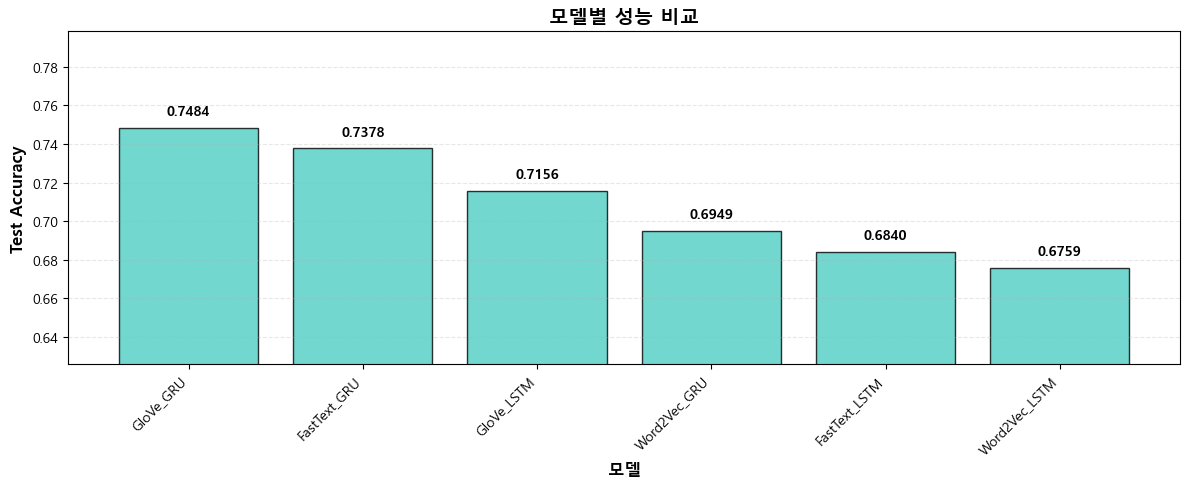

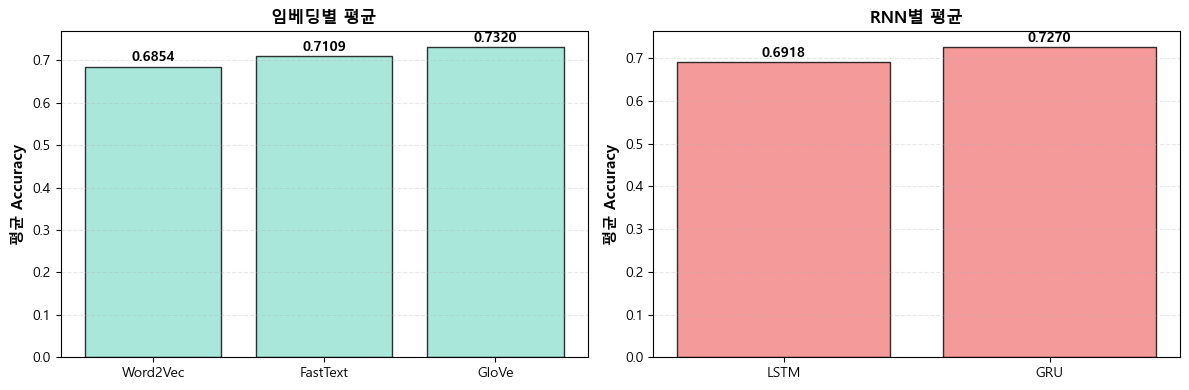


임베딩별 평균:
  Word2Vec: 0.6854
  FastText: 0.7109
  GloVe: 0.7320

RNN별 평균:
  LSTM: 0.6918
  GRU: 0.7270


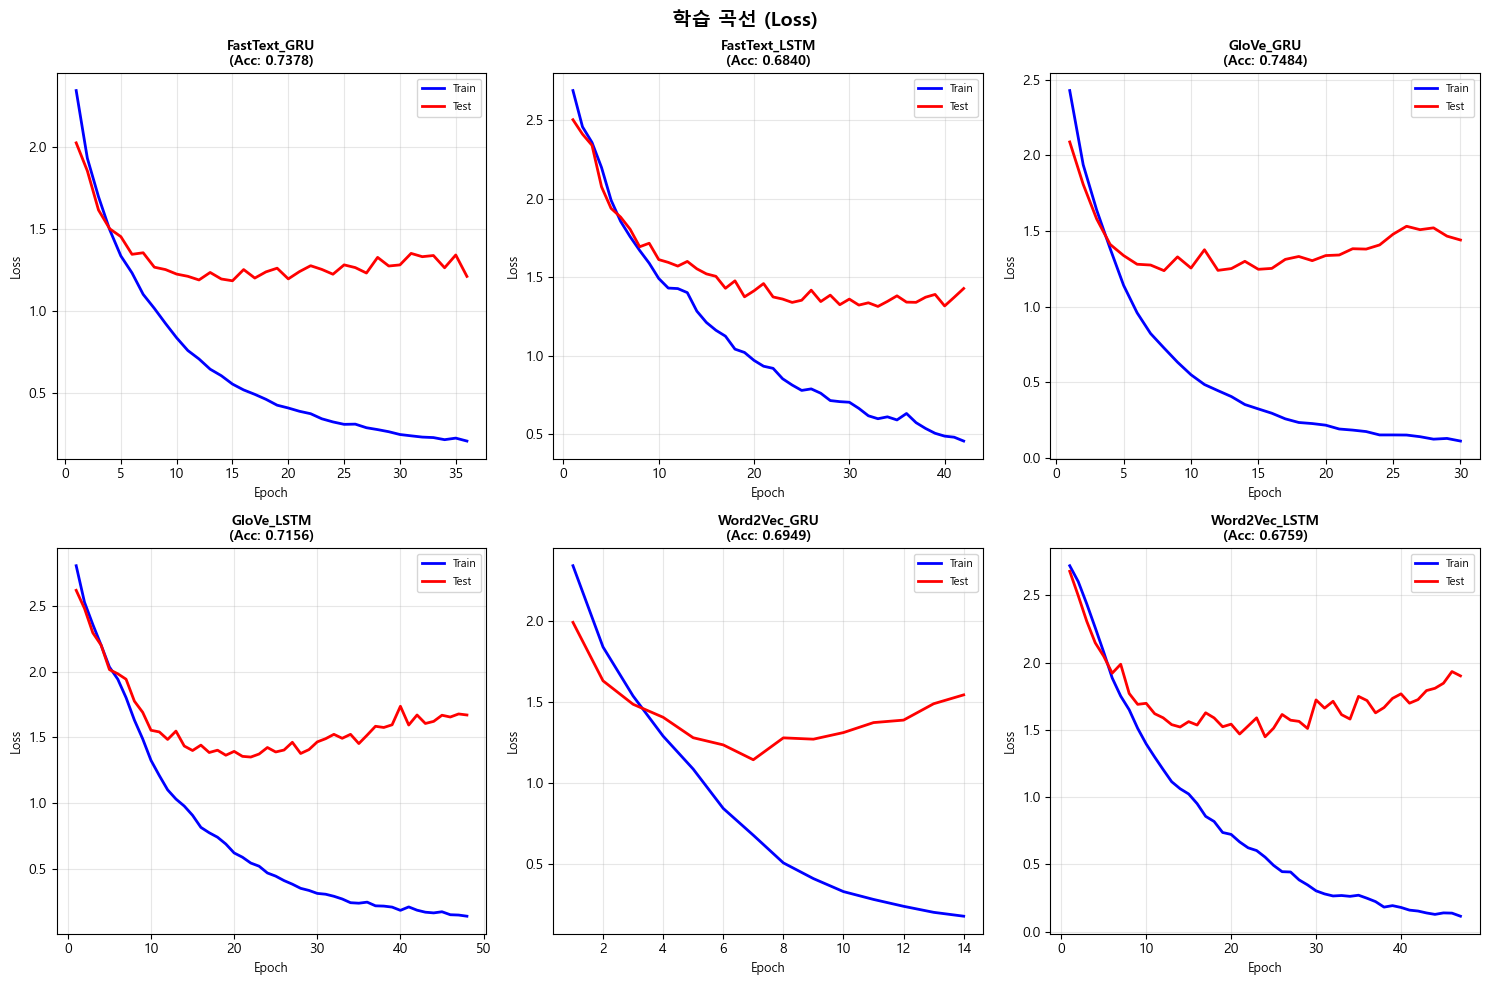


✓ 시각화 완료!


In [65]:
# 1. 한글 폰트 설정 (Windows/macOS 자동 감지)
import platform
import matplotlib.pyplot as plt

def setup_korean_font():
    system = platform.system()
    if system == 'Windows':
        font_name = 'Malgun Gothic'
    elif system == 'Darwin':
        font_name = 'AppleGothic'
    else:
        font_name = 'NanumGothic'

    plt.rcParams['font.family'] = font_name
    plt.rcParams['axes.unicode_minus'] = False
    print(f"✓ 한글 폰트: {font_name} ({system})")

setup_korean_font()


# 2. 저장된 모델 정보 로드 
import torch
import os

def load_all_saved_models(model_dir='model'):
    """model 폴더의 모든 _best.pth 파일 로드"""
    results = {}

    checkpoint_files = [f for f in os.listdir(model_dir) if f.endswith('_best.pth')]

    print(f"\n{'='*60}")
    print(f"저장된 모델 로드 중... ({len(checkpoint_files)}개)")
    print(f"{'='*60}\n")

    for file_name in sorted(checkpoint_files):
        model_path = os.path.join(model_dir, file_name)
        model_name = file_name.replace('_best.pth', '')

        checkpoint = torch.load(model_path, map_location='cpu')

        results[model_name] = {
            'test_accuracy': checkpoint['test_acc'],
            'test_loss': checkpoint['test_loss'],
            'epoch': checkpoint['epoch'],
            'history': checkpoint.get('history', {}),
        }

        print(f"✓ {model_name:20s} | Acc: {checkpoint['test_acc']:.4f}")

    print(f"\n{'='*60}\n")
    return results

# 모델 로드
results = load_all_saved_models('model')


# 3. 성능 비교 테이블 
import pandas as pd

summary_data = []
for model_name, result in results.items():
    summary_data.append({
        '모델': model_name,
        'Accuracy': result['test_accuracy'],
        'Loss': result['test_loss'],
        'Epoch': result['epoch']
    })

df = pd.DataFrame(summary_data).sort_values('Accuracy', ascending=False)

print("모델별 성능:")
print("-"*60)
print(df.to_string(index=False))
print("-"*60)
print(f"\n★ 최고: {df.iloc[0]['모델']} (Acc: {df.iloc[0]['Accuracy']:.4f})\n")


# 4. 막대 그래프 
plt.figure(figsize=(12, 5))

models = df['모델'].values
accs = df['Accuracy'].values
colors = ['#FF6B6B' if 'BERT' in m else '#4ECDC4' for m in models]

bars = plt.bar(range(len(models)), accs, color=colors, alpha=0.8, edgecolor='black')

for i, (m, a) in enumerate(zip(models, accs)):
    plt.text(i, a + 0.005, f'{a:.4f}', ha='center', va='bottom',
             fontsize=10, fontweight='bold')

plt.xlabel('모델', fontsize=12, fontweight='bold')
plt.ylabel('Test Accuracy', fontsize=12, fontweight='bold')
plt.title('모델별 성능 비교', fontsize=14, fontweight='bold')
plt.xticks(range(len(models)), models, rotation=45, ha='right')
plt.ylim([min(accs) - 0.05, max(accs) + 0.05])
plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()


#  5. 임베딩별/RNN별 평균 
import numpy as np

rnn_results = {k: v for k, v in results.items() if 'LSTM' in k or 'GRU' in k}

# rnn_results가 정의되어 있고, 6개 이상의 모델이 있는지 확인합니다.
if 'rnn_results' in locals() and len(rnn_results) >= 6:
    # 1. 임베딩별 평균 정확도 계산
    embedding_avg = {}
    for emb in ['Word2Vec', 'FastText', 'GloVe']:
        accs = [rnn_results[f"{emb}_{rnn}"]['test_accuracy']
                for rnn in ['LSTM', 'GRU'] if f"{emb}_{rnn}" in rnn_results]
        if accs:
            embedding_avg[emb] = np.mean(accs)
    
    # 2. RNN 모델별 평균 정확도 계산
    rnn_avg = {}
    for rnn in ['LSTM', 'GRU']:
        accs = [rnn_results[f"{emb}_{rnn}"]['test_accuracy']
                for emb in ['Word2Vec', 'FastText', 'GloVe'] if f"{emb}_{rnn}" in rnn_results]
        if accs:
            rnn_avg[rnn] = np.mean(accs)

    # 시각화
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # 임베딩별
    ax1 = axes[0]
    names = list(embedding_avg.keys())
    values = list(embedding_avg.values())
    bars = ax1.bar(names, values, color='#95E1D3', alpha=0.8, edgecolor='black')
    for bar, val in zip(bars, values):
        ax1.text(bar.get_x() + bar.get_width()/2, val + 0.005, f'{val:.4f}',
                ha='center', va='bottom', fontsize=10, fontweight='bold')
    ax1.set_ylabel('평균 Accuracy', fontsize=11, fontweight='bold')
    ax1.set_title('임베딩별 평균', fontsize=12, fontweight='bold')
    ax1.grid(axis='y', alpha=0.3, linestyle='--')

    # RNN별
    ax2 = axes[1]
    names = list(rnn_avg.keys())
    values = list(rnn_avg.values())
    bars = ax2.bar(names, values, color='#F38181', alpha=0.8, edgecolor='black')
    for bar, val in zip(bars, values):
        ax2.text(bar.get_x() + bar.get_width()/2, val + 0.005, f'{val:.4f}',
                ha='center', va='bottom', fontsize=10, fontweight='bold')
    ax2.set_ylabel('평균 Accuracy', fontsize=11, fontweight='bold')
    ax2.set_title('RNN별 평균', fontsize=12, fontweight='bold')
    ax2.grid(axis='y', alpha=0.3, linestyle='--')

    plt.tight_layout()
    plt.show()

    print("\n임베딩별 평균:")
    for k, v in embedding_avg.items():
        print(f"  {k}: {v:.4f}")

    print("\nRNN별 평균:")
    for k, v in rnn_avg.items():
        print(f"  {k}: {v:.4f}")


# 6. 학습 곡선 (history가 있는 경우)
models_with_history = {k: v for k, v in results.items()
                       if v['history'] and v['history'].get('train_loss')}

if models_with_history:
    num = len(models_with_history)
    nrows = (num + 2) // 3
    ncols = min(3, num)

    fig, axes = plt.subplots(nrows, ncols, figsize=(15, 5*nrows))
    fig.suptitle('학습 곡선 (Loss)', fontsize=14, fontweight='bold')

    if nrows == 1:
        axes = axes.reshape(1, -1) if num > 1 else np.array([[axes]])

    for idx, (name, res) in enumerate(sorted(models_with_history.items())):
        row, col = idx // ncols, idx % ncols
        ax = axes[row, col] if nrows > 1 or ncols > 1 else axes[0, 0]

        h = res['history']
        epochs = range(1, len(h['train_loss']) + 1)

        ax.plot(epochs, h['train_loss'], 'b-', label='Train', linewidth=2)
        ax.plot(epochs, h['test_loss'], 'r-', label='Test', linewidth=2)

        color = 'red' if 'BERT' in name else 'black'
        ax.set_title(f'{name}\n(Acc: {res["test_accuracy"]:.4f})',
                    fontsize=10, fontweight='bold', color=color)
        ax.set_xlabel('Epoch', fontsize=9)
        ax.set_ylabel('Loss', fontsize=9)
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)

    # 빈 subplot 제거
    for idx in range(num, nrows * ncols):
        row, col = idx // ncols, idx % ncols
        fig.delaxes(axes[row, col])

    plt.tight_layout()
    plt.show()

print("\n✓ 시각화 완료!")


#### 학습 곡선 분석

**과적합 현상 확인**

**관찰되는 패턴**
- Train Loss: 지속적으로 감소
- Test Loss: 특정 시점 이후 정체 또는 증가
- Train-Test Gap: 학습이 진행될수록 격차 확대

**모델별 과적합 시작 시점**
- Word2Vec_GRU: 약 7 에포크 이후
- Word2Vec_LSTM: 약 10-15 에포크 이후
- FastText_GRU: 약 20 에포크 이후
- FastText_LSTM: 약 15-20 에포크 이후
- GloVe_GRU: 약 10 에포크 이후
- GloVe_LSTM: 약 20 에포크 이후

**추가 학습 필요성**
Epoch을 늘려도 다음 이유로 추가 학습은 불필요합니다:
- Test loss가 더 이상 개선되지 않음
- 오히려 Test loss가 증가하는 경향
- Train-Test 격차만 더 벌어질 가능성

**개선 방안**
RNN 이 아닌 트랜스포머랑 BERT 랑 비교해보면 어떨까 싶어서 작성해봤습니다.

In [79]:
# BERT 모델 클래스 정의
import torch
import torch.nn as nn
from transformers import BertModel, BertTokenizer

class BERTClassifier(nn.Module):
    """
    BERT 기반 텍스트 분류 모델
    """
    def __init__(self, num_classes=20, bert_model_name='bert-base-uncased', dropout=0.3):
        super(BERTClassifier, self).__init__()

        # BERT 모델 로드
        self.bert = BertModel.from_pretrained(bert_model_name)

        # BERT의 hidden size (768 for base)
        self.hidden_size = self.bert.config.hidden_size

        # Dropout
        self.dropout = nn.Dropout(dropout)

        # 분류 레이어
        self.classifier = nn.Linear(self.hidden_size, num_classes)

    def forward(self, input_ids, attention_mask):
        # BERT 인코딩
        outputs = self.bert(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        # [CLS] 토큰 출력 사용
        pooled_output = outputs.pooler_output

        # Dropout 적용
        pooled_output = self.dropout(pooled_output)

        # 분류
        logits = self.classifier(pooled_output)

        return logits

print("✓ BERTClassifier 클래스 정의 완료")

✓ BERTClassifier 클래스 정의 완료


In [80]:
# BERT용 데이터셋 및 데이터로더 생성
from torch.utils.data import Dataset, DataLoader
BATCH_SIZE = 32

class BERTDataset(Dataset):
    """BERT 모델용 데이터셋"""
    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts[idx]
        label = self.labels[idx]

        # 토크나이징
        encoding = self.tokenizer.encode_plus(
            text,
            add_special_tokens=True,
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt'
        )

        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'label': torch.tensor(label, dtype=torch.long)
        }

# BERT 토크나이저 초기화
bert_tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

# BERT용 데이터셋 생성
bert_train_dataset = BERTDataset(
    texts=train_data.data,
    labels=train_data.target,
    tokenizer=bert_tokenizer,
    max_length=128
)

bert_test_dataset = BERTDataset(
    texts=test_data.data,
    labels=test_data.target,
    tokenizer=bert_tokenizer,
    max_length=128
)

# 데이터로더 생성
bert_train_loader = DataLoader(
    bert_train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

bert_test_loader = DataLoader(
    bert_test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print(f"✓ BERT 데이터셋 생성 완료")
print(f"  - Train 샘플: {len(bert_train_dataset)}")
print(f"  - Test 샘플: {len(bert_test_dataset)}")
print(f"  - Max Length: 128")

d:\jupyter\Anaconda\install\envs\part3\lib\site-packages\huggingface_hub\file_download.py:942: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


✓ BERT 데이터셋 생성 완료
  - Train 샘플: 11314
  - Test 샘플: 7532
  - Max Length: 128


In [81]:
# BERT 모델 학습 및 평가 함수
def train_bert_model(model, train_loader, test_loader, criterion, optimizer,
                     device, num_epochs=10, patience=3, model_name='BERT'):
    """BERT 모델 학습 함수"""
    import os
    from tqdm import tqdm

    model = model.to(device)

    history = {
        'train_loss': [],
        'train_acc': [],
        'test_loss': [],
        'test_acc': []
    }
    
    best_test_loss = float('inf')
    best_test_acc = 0.0
    best_model_state = None
    patience_counter = 0

    model_dir = 'model'
    os.makedirs(model_dir, exist_ok=True)

    print(f"\n{'='*60}")
    print(f"BERT 모델 학습 시작")
    print(f"{'='*60}")

    for epoch in range(num_epochs):
        # 훈련 단계
        model.train()
        train_loss = 0.0
        train_correct = 0
        train_total = 0

        train_pbar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs} [Train]')
        for batch in train_pbar:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['label'].to(device)

            optimizer.zero_grad()
            outputs = model(input_ids, attention_mask)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * input_ids.size(0)
            _, predicted = torch.max(outputs, 1)
            train_total += labels.size(0)
            train_correct += (predicted == labels).sum().item()

            train_pbar.set_postfix({
                'loss': f'{loss.item():.4f}',
                'acc': f'{100.*train_correct/train_total:.2f}%'
            })

        train_loss = train_loss / train_total
        train_acc = train_correct / train_total

        # 검증 단계
        model.eval()
        test_loss = 0.0
        test_correct = 0
        test_total = 0

        with torch.no_grad():
            for batch in test_loader:
                input_ids = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                labels = batch['label'].to(device)

                outputs = model(input_ids, attention_mask)
                loss = criterion(outputs, labels)

                test_loss += loss.item() * input_ids.size(0)
                _, predicted = torch.max(outputs, 1)
                test_total += labels.size(0)
                test_correct += (predicted == labels).sum().item()

        test_loss = test_loss / test_total
        test_acc = test_correct / test_total

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['test_loss'].append(test_loss)
        history['test_acc'].append(test_acc)

        print(f"Epoch [{epoch+1}/{num_epochs}]")
        print(f"  Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}")
        print(f"  Test Loss:  {test_loss:.4f}, Test Acc:  {test_acc:.4f}")

        # Best 모델 저장
        if test_loss < best_test_loss:
            best_test_loss = test_loss
            best_test_acc = test_acc
            best_model_state = model.state_dict().copy()
            patience_counter = 0

            model_save_path = os.path.join(model_dir, f'{model_name}_best.pth')
            torch.save({
                'epoch': epoch + 1,
                'model_state_dict': best_model_state,
                'optimizer_state_dict': optimizer.state_dict(),
                'test_acc': best_test_acc,
                'test_loss': test_loss,
                'history': history
            }, model_save_path)

            print(f"  ✓ Best 모델 저장! (Test Loss: {best_test_loss:.4f}, Test Acc: {best_test_acc:.4f})")
        else:
            patience_counter += 1
            print(f"  Patience: {patience_counter}/{patience}")

        if patience_counter >= patience:
            print(f"\n⚠ Early stopping at epoch {epoch+1}")
            break

        print()

    print(f"{'='*60}")
    print(f"학습 완료! Best Test Loss: {best_test_loss:.4f}, Best Test Acc: {best_test_acc:.4f}")
    print(f"{'='*60}\n")

    return history, best_model_state, model_save_path


def evaluate_bert(model, dataloader, criterion, device):
    """BERT 모델 평가 함수"""
    model.eval()

    total_loss = 0.0
    all_predictions = []
    all_labels = []
    total_samples = 0

    with torch.no_grad():
        for batch in dataloader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['label'].to(device)

            outputs = model(input_ids, attention_mask)
            loss = criterion(outputs, labels)

            total_loss += loss.item() * input_ids.size(0)
            total_samples += input_ids.size(0)

            _, predicted = torch.max(outputs, 1)
            all_predictions.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / total_samples
    accuracy = np.mean(np.array(all_predictions) == np.array(all_labels))

    return avg_loss, accuracy, all_predictions, all_labels

print("✓ BERT 학습/평가 함수 정의 완료")

✓ BERT 학습/평가 함수 정의 완료


In [82]:
# BERT 모델 학습 또는 로드

model_name = 'BERT'
model_dir = 'model' 
model_save_path = os.path.join(model_dir, f'{model_name}_best.pth')

# 모델 폴더 확인 및 생성
if not os.path.exists(model_dir):
    os.makedirs(model_dir)
    print(f"✓ '{model_dir}' 폴더 생성됨")

# BERT 모델 생성
bert_model = BERTClassifier(num_classes=20, bert_model_name='bert-base-uncased', dropout=0.3)
bert_model = bert_model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(bert_model.parameters(), lr=2e-5)

bert_loaded_from_checkpoint = False

# 체크포인트 존재 여부 확인
if os.path.exists(model_save_path):
    print(f"✓ BERT 체크포인트 발견: {model_save_path}")
    
    # 파일 크기 확인
    file_size = os.path.getsize(model_save_path) / (1024 * 1024)
    print(f"  파일 크기: {file_size:.2f} MB")
    print("학습을 건너뛰고 모델을 로드합니다...\n")
    
    try:
        checkpoint = torch.load(model_save_path,map_location=device)
        bert_model.load_state_dict(checkpoint['model_state_dict'])

        if 'history' in checkpoint:
            bert_history = checkpoint['history']
        else:
            bert_history = {
                'train_loss': [],
                'train_acc': [],
                'test_loss': [],
                'test_acc': []
            }

        bert_best_state = bert_model.state_dict().copy()
        bert_loaded_from_checkpoint = True

        print(f"✓ BERT 모델 로드 완료")
        print(f"  - Epoch: {checkpoint['epoch']}")
        print(f"  - Test Accuracy: {checkpoint['test_acc']:.4f}")

    except Exception as e:
        print(f"✗ 체크포인트 로드 실패: {e}")
        print("새로 학습을 시작합니다...\n")
        bert_loaded_from_checkpoint = False

# 체크포인트가 없거나 로드 실패 시 학습
if not bert_loaded_from_checkpoint:
    print(f"✗ BERT 체크포인트 없음. 새로 학습을 시작합니다...\n")

    bert_history, bert_best_state, model_save_path = train_bert_model(
        model=bert_model,
        train_loader=bert_train_loader,
        test_loader=bert_test_loader,
        criterion=criterion,
        optimizer=optimizer,
        device=device,
        num_epochs=50,
        patience=7,
        model_name=model_name
    )
    
    # 학습 후 저장 확인 ← 추가
    print(f"\n{'='*60}")
    print(f"저장 확인")
    print(f"{'='*60}")
    if os.path.exists(model_save_path):
        file_size = os.path.getsize(model_save_path) / (1024 * 1024)
        print(f"✓ 체크포인트 저장됨: {model_save_path}")
        print(f"  파일 크기: {file_size:.2f} MB")
    else:
        print(f"✗ 저장 실패: {model_save_path}")
        
# 최종 평가
bert_model.load_state_dict(bert_best_state)
bert_test_loss, bert_test_acc, bert_predictions, bert_labels = evaluate_bert(
    bert_model, bert_test_loader, criterion, device
)

print(f"\n✓ BERT 최종 Test Accuracy: {bert_test_acc:.4f}")
if bert_loaded_from_checkpoint:
    print(f"  (체크포인트에서 로드됨)")

✓ BERT 체크포인트 발견: model\BERT_best.pth
  파일 크기: 1253.33 MB
학습을 건너뛰고 모델을 로드합니다...

✓ BERT 모델 로드 완료
  - Epoch: 3
  - Test Accuracy: 0.7252

✓ BERT 최종 Test Accuracy: 0.7252
  (체크포인트에서 로드됨)


In [83]:
# all_results가 없으면 생성
if 'all_results' not in dir():
    all_results = {}
    
all_results['BERT'] = {
    'history': bert_history,
    'best_state': bert_best_state,
    'test_accuracy': bert_test_acc,
    'predictions': bert_predictions,
    'labels': bert_labels,
    'save_path': model_save_path,
    'loaded_from_checkpoint': bert_loaded_from_checkpoint
}

# 최종 확인
print(f"\n{'='*60}")
print(f"최종 파일 확인")
print(f"{'='*60}")
print(f"저장 경로: {model_save_path}")
print(f"파일 존재: {'✓' if os.path.exists(model_save_path) else '✗'}")
if os.path.exists(model_save_path):
    file_size = os.path.getsize(model_save_path) / (1024 * 1024)
    print(f"파일 크기: {file_size:.2f} MB")


최종 파일 확인
저장 경로: model\BERT_best.pth
파일 존재: ✓
파일 크기: 1253.33 MB



저장된 모델 로드 중... (7개)

✓ BERT                 | Acc: 0.7252
✓ FastText_GRU         | Acc: 0.7378
✓ FastText_LSTM        | Acc: 0.6840
✓ GloVe_GRU            | Acc: 0.7484
✓ GloVe_LSTM           | Acc: 0.7156
✓ Word2Vec_GRU         | Acc: 0.6949
✓ Word2Vec_LSTM        | Acc: 0.6759


모델별 성능:
------------------------------------------------------------
           모델  Accuracy     Loss  Epoch
    GloVe_GRU  0.748407 1.440648     30
 FastText_GRU  0.737785 1.211964     36
         BERT  0.725173 0.963532      3
   GloVe_LSTM  0.715613 1.669939     48
 Word2Vec_GRU  0.694902 1.543712     14
FastText_LSTM  0.684015 1.428484     42
Word2Vec_LSTM  0.675916 1.901077     47
------------------------------------------------------------

★ 최고: GloVe_GRU (Acc: 0.7484)



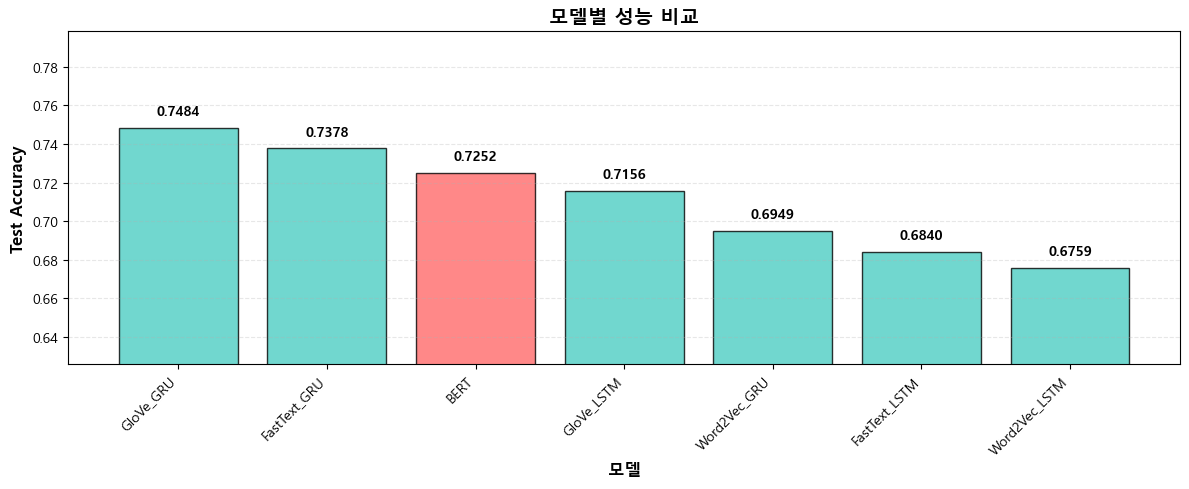

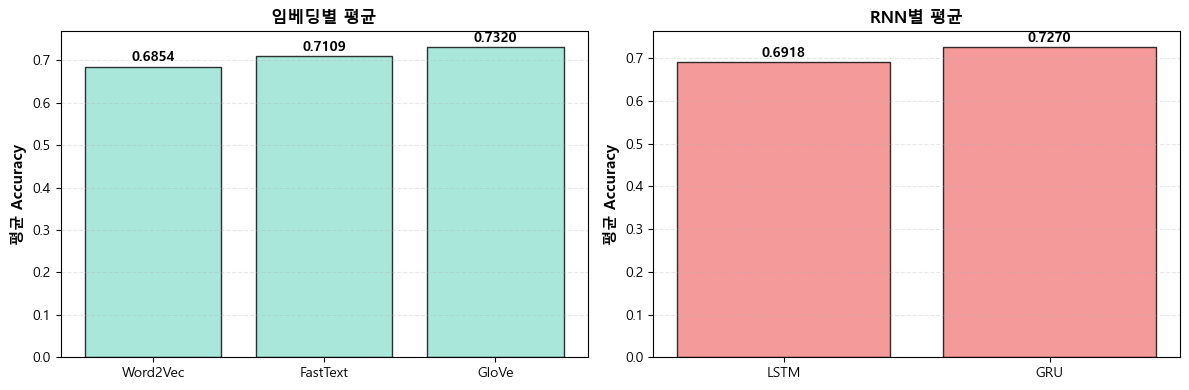


임베딩별 평균:
  Word2Vec: 0.6854
  FastText: 0.7109
  GloVe: 0.7320

RNN별 평균:
  LSTM: 0.6918
  GRU: 0.7270


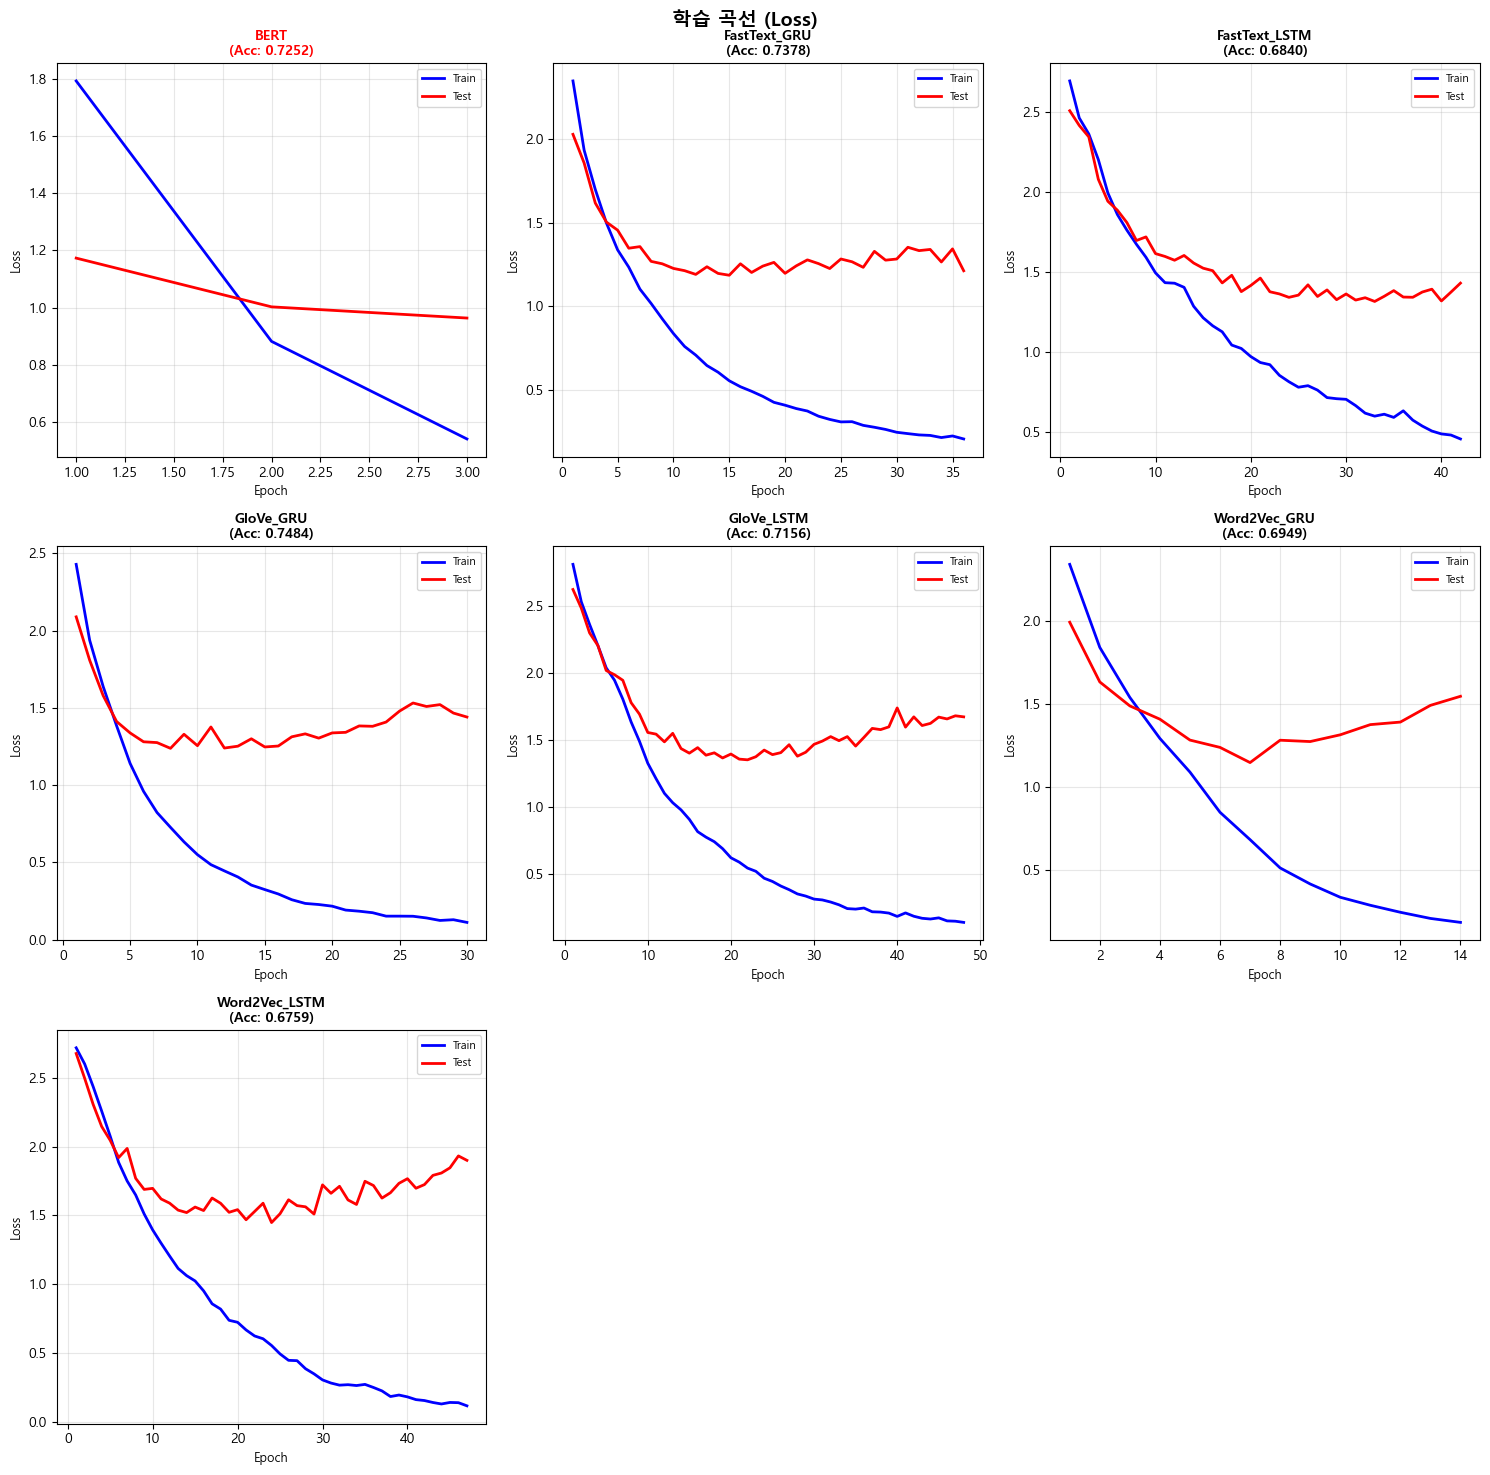


✓ 시각화 완료!


In [70]:
# 1. 저장된 모델 정보 로드 
import torch
import os

def load_all_saved_models(model_dir='model'):
    """model 폴더의 모든 _best.pth 파일 로드"""
    results = {}

    checkpoint_files = [f for f in os.listdir(model_dir) if f.endswith('_best.pth')]

    print(f"\n{'='*60}")
    print(f"저장된 모델 로드 중... ({len(checkpoint_files)}개)")
    print(f"{'='*60}\n")

    for file_name in sorted(checkpoint_files):
        model_path = os.path.join(model_dir, file_name)
        model_name = file_name.replace('_best.pth', '')

        checkpoint = torch.load(model_path, map_location='cpu')

        results[model_name] = {
            'test_accuracy': checkpoint['test_acc'],
            'test_loss': checkpoint['test_loss'],
            'epoch': checkpoint['epoch'],
            'history': checkpoint.get('history', {}),
        }

        print(f"✓ {model_name:20s} | Acc: {checkpoint['test_acc']:.4f}")

    print(f"\n{'='*60}\n")
    return results

# 모델 로드
results = load_all_saved_models('model')


# 2. 성능 비교 테이블 
import pandas as pd

summary_data = []
for model_name, result in results.items():
    summary_data.append({
        '모델': model_name,
        'Accuracy': result['test_accuracy'],
        'Loss': result['test_loss'],
        'Epoch': result['epoch']
    })

df = pd.DataFrame(summary_data).sort_values('Accuracy', ascending=False)

print("모델별 성능:")
print("-"*60)
print(df.to_string(index=False))
print("-"*60)
print(f"\n★ 최고: {df.iloc[0]['모델']} (Acc: {df.iloc[0]['Accuracy']:.4f})\n")


# 3. 막대 그래프 
plt.figure(figsize=(12, 5))

models = df['모델'].values
accs = df['Accuracy'].values
colors = ['#FF6B6B' if 'BERT' in m else '#4ECDC4' for m in models]

bars = plt.bar(range(len(models)), accs, color=colors, alpha=0.8, edgecolor='black')

for i, (m, a) in enumerate(zip(models, accs)):
    plt.text(i, a + 0.005, f'{a:.4f}', ha='center', va='bottom',
             fontsize=10, fontweight='bold')

plt.xlabel('모델', fontsize=12, fontweight='bold')
plt.ylabel('Test Accuracy', fontsize=12, fontweight='bold')
plt.title('모델별 성능 비교', fontsize=14, fontweight='bold')
plt.xticks(range(len(models)), models, rotation=45, ha='right')
plt.ylim([min(accs) - 0.05, max(accs) + 0.05])
plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()


#  4. 임베딩별/RNN별 평균 
import numpy as np

rnn_results = {k: v for k, v in results.items() if 'LSTM' in k or 'GRU' in k}

# rnn_results가 정의되어 있고, 6개 이상의 모델이 있는지 확인합니다.
if 'rnn_results' in locals() and len(rnn_results) >= 6:
    # 1. 임베딩별 평균 정확도 계산
    embedding_avg = {}
    for emb in ['Word2Vec', 'FastText', 'GloVe']:
        accs = [rnn_results[f"{emb}_{rnn}"]['test_accuracy']
                for rnn in ['LSTM', 'GRU'] if f"{emb}_{rnn}" in rnn_results]
        if accs:
            embedding_avg[emb] = np.mean(accs)
    
    # 2. RNN 모델별 평균 정확도 계산
    rnn_avg = {}
    for rnn in ['LSTM', 'GRU']:
        accs = [rnn_results[f"{emb}_{rnn}"]['test_accuracy']
                for emb in ['Word2Vec', 'FastText', 'GloVe'] if f"{emb}_{rnn}" in rnn_results]
        if accs:
            rnn_avg[rnn] = np.mean(accs)

    # 시각화
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # 임베딩별
    ax1 = axes[0]
    names = list(embedding_avg.keys())
    values = list(embedding_avg.values())
    bars = ax1.bar(names, values, color='#95E1D3', alpha=0.8, edgecolor='black')
    for bar, val in zip(bars, values):
        ax1.text(bar.get_x() + bar.get_width()/2, val + 0.005, f'{val:.4f}',
                ha='center', va='bottom', fontsize=10, fontweight='bold')
    ax1.set_ylabel('평균 Accuracy', fontsize=11, fontweight='bold')
    ax1.set_title('임베딩별 평균', fontsize=12, fontweight='bold')
    ax1.grid(axis='y', alpha=0.3, linestyle='--')

    # RNN별
    ax2 = axes[1]
    names = list(rnn_avg.keys())
    values = list(rnn_avg.values())
    bars = ax2.bar(names, values, color='#F38181', alpha=0.8, edgecolor='black')
    for bar, val in zip(bars, values):
        ax2.text(bar.get_x() + bar.get_width()/2, val + 0.005, f'{val:.4f}',
                ha='center', va='bottom', fontsize=10, fontweight='bold')
    ax2.set_ylabel('평균 Accuracy', fontsize=11, fontweight='bold')
    ax2.set_title('RNN별 평균', fontsize=12, fontweight='bold')
    ax2.grid(axis='y', alpha=0.3, linestyle='--')

    plt.tight_layout()
    plt.show()

    print("\n임베딩별 평균:")
    for k, v in embedding_avg.items():
        print(f"  {k}: {v:.4f}")

    print("\nRNN별 평균:")
    for k, v in rnn_avg.items():
        print(f"  {k}: {v:.4f}")


# 5. 학습 곡선 (history가 있는 경우)
models_with_history = {k: v for k, v in results.items()
                       if v['history'] and v['history'].get('train_loss')}

if models_with_history:
    num = len(models_with_history)
    nrows = (num + 2) // 3
    ncols = min(3, num)

    fig, axes = plt.subplots(nrows, ncols, figsize=(15, 5*nrows))
    fig.suptitle('학습 곡선 (Loss)', fontsize=14, fontweight='bold')

    if nrows == 1:
        axes = axes.reshape(1, -1) if num > 1 else np.array([[axes]])

    for idx, (name, res) in enumerate(sorted(models_with_history.items())):
        row, col = idx // ncols, idx % ncols
        ax = axes[row, col] if nrows > 1 or ncols > 1 else axes[0, 0]

        h = res['history']
        epochs = range(1, len(h['train_loss']) + 1)

        ax.plot(epochs, h['train_loss'], 'b-', label='Train', linewidth=2)
        ax.plot(epochs, h['test_loss'], 'r-', label='Test', linewidth=2)

        color = 'red' if 'BERT' in name else 'black'
        ax.set_title(f'{name}\n(Acc: {res["test_accuracy"]:.4f})',
                    fontsize=10, fontweight='bold', color=color)
        ax.set_xlabel('Epoch', fontsize=9)
        ax.set_ylabel('Loss', fontsize=9)
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)

    # 빈 subplot 제거
    for idx in range(num, nrows * ncols):
        row, col = idx // ncols, idx % ncols
        fig.delaxes(axes[row, col])

    plt.tight_layout()
    plt.show()

print("\n✓ 시각화 완료!")


In [84]:
from transformers import BertTokenizer

# BERT Tokenizer 로드
bert_tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')


print("="*80)
print("모델별 예측 비교 분석")
print("="*80)

# ========================================================================
# 1. 모델 예측 함수 정의
# ========================================================================

def predict_rnn_model(model, text_sequence, device):
    """RNN 모델로 예측"""
    model.eval()
    with torch.no_grad():
        sequence = torch.LongTensor(text_sequence).unsqueeze(0).to(device)
        output = model(sequence)
        probabilities = torch.softmax(output, dim=1).cpu().numpy()[0]
        prediction = output.argmax(dim=1).item()
    return prediction, probabilities


def predict_bert_model(model, text, tokenizer, device, max_length=128):
    """BERT 모델로 예측"""
    model.eval()
    
    encoding = tokenizer.encode_plus(
        text,
        add_special_tokens=True,
        max_length=max_length,
        padding='max_length',
        truncation=True,
        return_attention_mask=True,
        return_tensors='pt'
    )
    
    input_ids = encoding['input_ids'].to(device)
    attention_mask = encoding['attention_mask'].to(device)
    
    with torch.no_grad():
        output = model(input_ids, attention_mask)
        probabilities = torch.softmax(output, dim=1).cpu().numpy()[0]
        prediction = output.argmax(dim=1).item()
    
    return prediction, probabilities


# ========================================================================
# 2. 샘플 선택 및 예측
# ========================================================================

def compare_models_on_samples(all_results, test_data, X_test, 
                               bert_tokenizer, device, 
                               num_samples=5, random_state=42):
    """
    여러 샘플에 대해 모든 모델의 예측 비교
    """
    np.random.seed(random_state)
    
    # 랜덤 샘플 선택
    total_samples = len(test_data.data)
    sample_indices = np.random.choice(total_samples, num_samples, replace=False)
    
    results = []
    
    for idx in sample_indices:
        # 실제 데이터
        true_label = test_data.target[idx]
        true_category = test_data.target_names[true_label]
        text = test_data.data[idx]
        sequence = X_test[idx]  # RNN용 인코딩된 시퀀스
        
        # 각 모델의 예측
        predictions = {}
        probabilities_dict = {}
        
        for model_name, result in all_results.items():
            try:
                if 'BERT' in model_name.upper():
                    # BERT 모델
                    model = BERTClassifier(num_classes=20, 
                                          bert_model_name='bert-base-uncased', 
                                          dropout=0.3)
                    model.load_state_dict(result['best_state'])
                    model = model.to(device)
                    
                    pred, probs = predict_bert_model(
                        model, text, bert_tokenizer, device
                    )
                else:
                    # RNN 모델
                    # 모델 재생성 (임베딩 행렬 필요)
                    emb_name = model_name.split('_')[0]
                    rnn_type = model_name.split('_')[1]
                    
                    # 임베딩 행렬 선택
                    if emb_name == 'Word2Vec':
                        emb_matrix = word2vec_embedding_matrix
                    elif emb_name == 'FastText':
                        emb_matrix = fasttext_embedding_matrix
                    elif emb_name == 'GloVe':
                        emb_matrix = glove_embedding_matrix
                    
                    model = create_model(rnn_type=rnn_type, 
                                        embedding_matrix=emb_matrix)
                    model.load_state_dict(result['best_state'])
                    model = model.to(device)
                    
                    pred, probs = predict_rnn_model(model, sequence, device)
                
                predictions[model_name] = pred
                probabilities_dict[model_name] = probs
                
            except Exception as e:
                print(f"  ✗ {model_name} 예측 실패: {e}")
                predictions[model_name] = -1
                probabilities_dict[model_name] = np.zeros(20)
        
        results.append({
            'index': idx,
            'text': text[:200] + '...' if len(text) > 200 else text,
            'true_label': true_label,
            'true_category': true_category,
            'predictions': predictions,
            'probabilities': probabilities_dict
        })
    
    return results


print("\n샘플 예측 수행 중...")
comparison_results = compare_models_on_samples(
    all_results=all_results,
    test_data=test_data,
    X_test=X_test,
    bert_tokenizer=bert_tokenizer,
    device=device,
    num_samples=10,  # 10개 샘플 비교
    random_state=42
)

print(f"✓ {len(comparison_results)}개 샘플 예측 완료\n")

모델별 예측 비교 분석

샘플 예측 수행 중...
✓ 10개 샘플 예측 완료



In [85]:
# ========================================================================
# 3. 결과 시각화 - 샘플별 예측 비교 테이블
# ========================================================================

print("="*80)
print("샘플별 모델 예측 비교")
print("="*80)

for i, result in enumerate(comparison_results, 1):
    print(f"\n{'='*80}")
    print(f"샘플 {i} (인덱스: {result['index']})")
    print(f"{'='*80}")
    print(f"\n실제 카테고리: {result['true_category']}")
    print(f"\n원문 (앞부분):")
    print(f"{result['text']}")
    print(f"\n{'-'*80}")
    print(f"{'모델':<20s} | {'예측 카테고리':<25s} | {'일치':<6s} | 확률")
    print(f"{'-'*80}")
    
    for model_name, pred_label in result['predictions'].items():
        if pred_label == -1:
            continue
        
        pred_category = test_data.target_names[pred_label]
        is_correct = '✓' if pred_label == result['true_label'] else '✗'
        confidence = result['probabilities'][model_name][pred_label]
        
        print(f"{model_name:<20s} | {pred_category:<25s} | {is_correct:<6s} | {confidence:.4f}")
    
    # 모델 일치도
    predictions_list = [p for p in result['predictions'].values() if p != -1]
    if predictions_list:
        most_common = Counter(predictions_list).most_common(1)[0]
        agreement = most_common[1] / len(predictions_list) * 100
        print(f"\n모델 일치도: {agreement:.1f}% ({most_common[1]}/{len(predictions_list)}개 모델 동의)")

샘플별 모델 예측 비교

샘플 1 (인덱스: 6716)

실제 카테고리: comp.sys.mac.hardware

원문 (앞부분):

In article <1qpc9g$4mr@bigboote.WPI.EDU> bchase@bigwpi.WPI.EDU (Bret Chase) writes:

Well, almost NuBUS 90 anyway, comprehensive bus contention between processors
is not supported in the current Maci...

--------------------------------------------------------------------------------
모델                   | 예측 카테고리                   | 일치     | 확률
--------------------------------------------------------------------------------
Word2Vec_LSTM        | comp.sys.mac.hardware     | ✓      | 0.9937
Word2Vec_GRU         | comp.sys.mac.hardware     | ✓      | 0.9244
FastText_LSTM        | comp.sys.mac.hardware     | ✓      | 0.8597
FastText_GRU         | comp.sys.mac.hardware     | ✓      | 0.9990
GloVe_LSTM           | comp.sys.mac.hardware     | ✓      | 0.9965
GloVe_GRU            | comp.sys.mac.hardware     | ✓      | 0.9935
BERT                 | comp.sys.mac.hardware     | ✓      | 0.7820

모델 일치도: 100.0% (7/7개 모델 동의


예측 일치도 분석



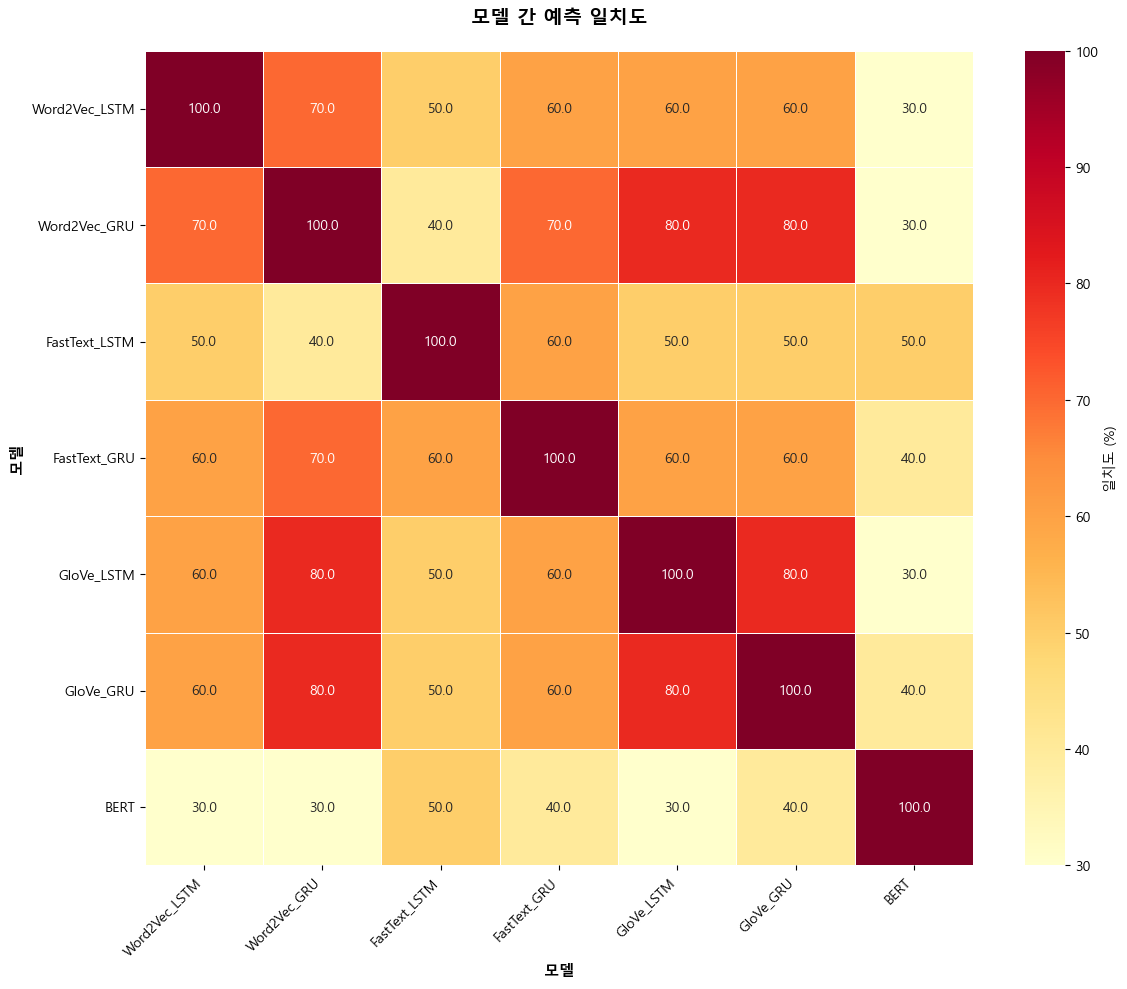

✓ 예측 일치도 히트맵 생성 완료


In [86]:
# ========================================================================
# 4. 예측 일치도 히트맵
# ========================================================================
import  seaborn as sns

print(f"\n{'='*80}")
print("예측 일치도 분석")
print(f"{'='*80}\n")

# 모델 이름 리스트
model_names = list(all_results.keys())

# 일치도 매트릭스 생성 (모델 간)
agreement_matrix = np.zeros((len(model_names), len(model_names)))

for i, model1 in enumerate(model_names):
    for j, model2 in enumerate(model_names):
        if i == j:
            agreement_matrix[i, j] = 100.0
        else:
            # 두 모델의 예측이 일치하는 비율
            agreements = 0
            total = 0
            
            for result in comparison_results:
                pred1 = result['predictions'].get(model1, -1)
                pred2 = result['predictions'].get(model2, -1)
                
                if pred1 != -1 and pred2 != -1:
                    if pred1 == pred2:
                        agreements += 1
                    total += 1
            
            if total > 0:
                agreement_matrix[i, j] = (agreements / total) * 100

# 히트맵 시각화
plt.figure(figsize=(12, 10))
sns.heatmap(agreement_matrix, 
            annot=True, 
            fmt='.1f',
            cmap='YlOrRd',
            xticklabels=model_names,
            yticklabels=model_names,
            cbar_kws={'label': '일치도 (%)'},
            linewidths=0.5)

plt.title('모델 간 예측 일치도', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('모델', fontsize=11, fontweight='bold')
plt.ylabel('모델', fontsize=11, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print("✓ 예측 일치도 히트맵 생성 완료")


샘플별 예측 분포 시각화



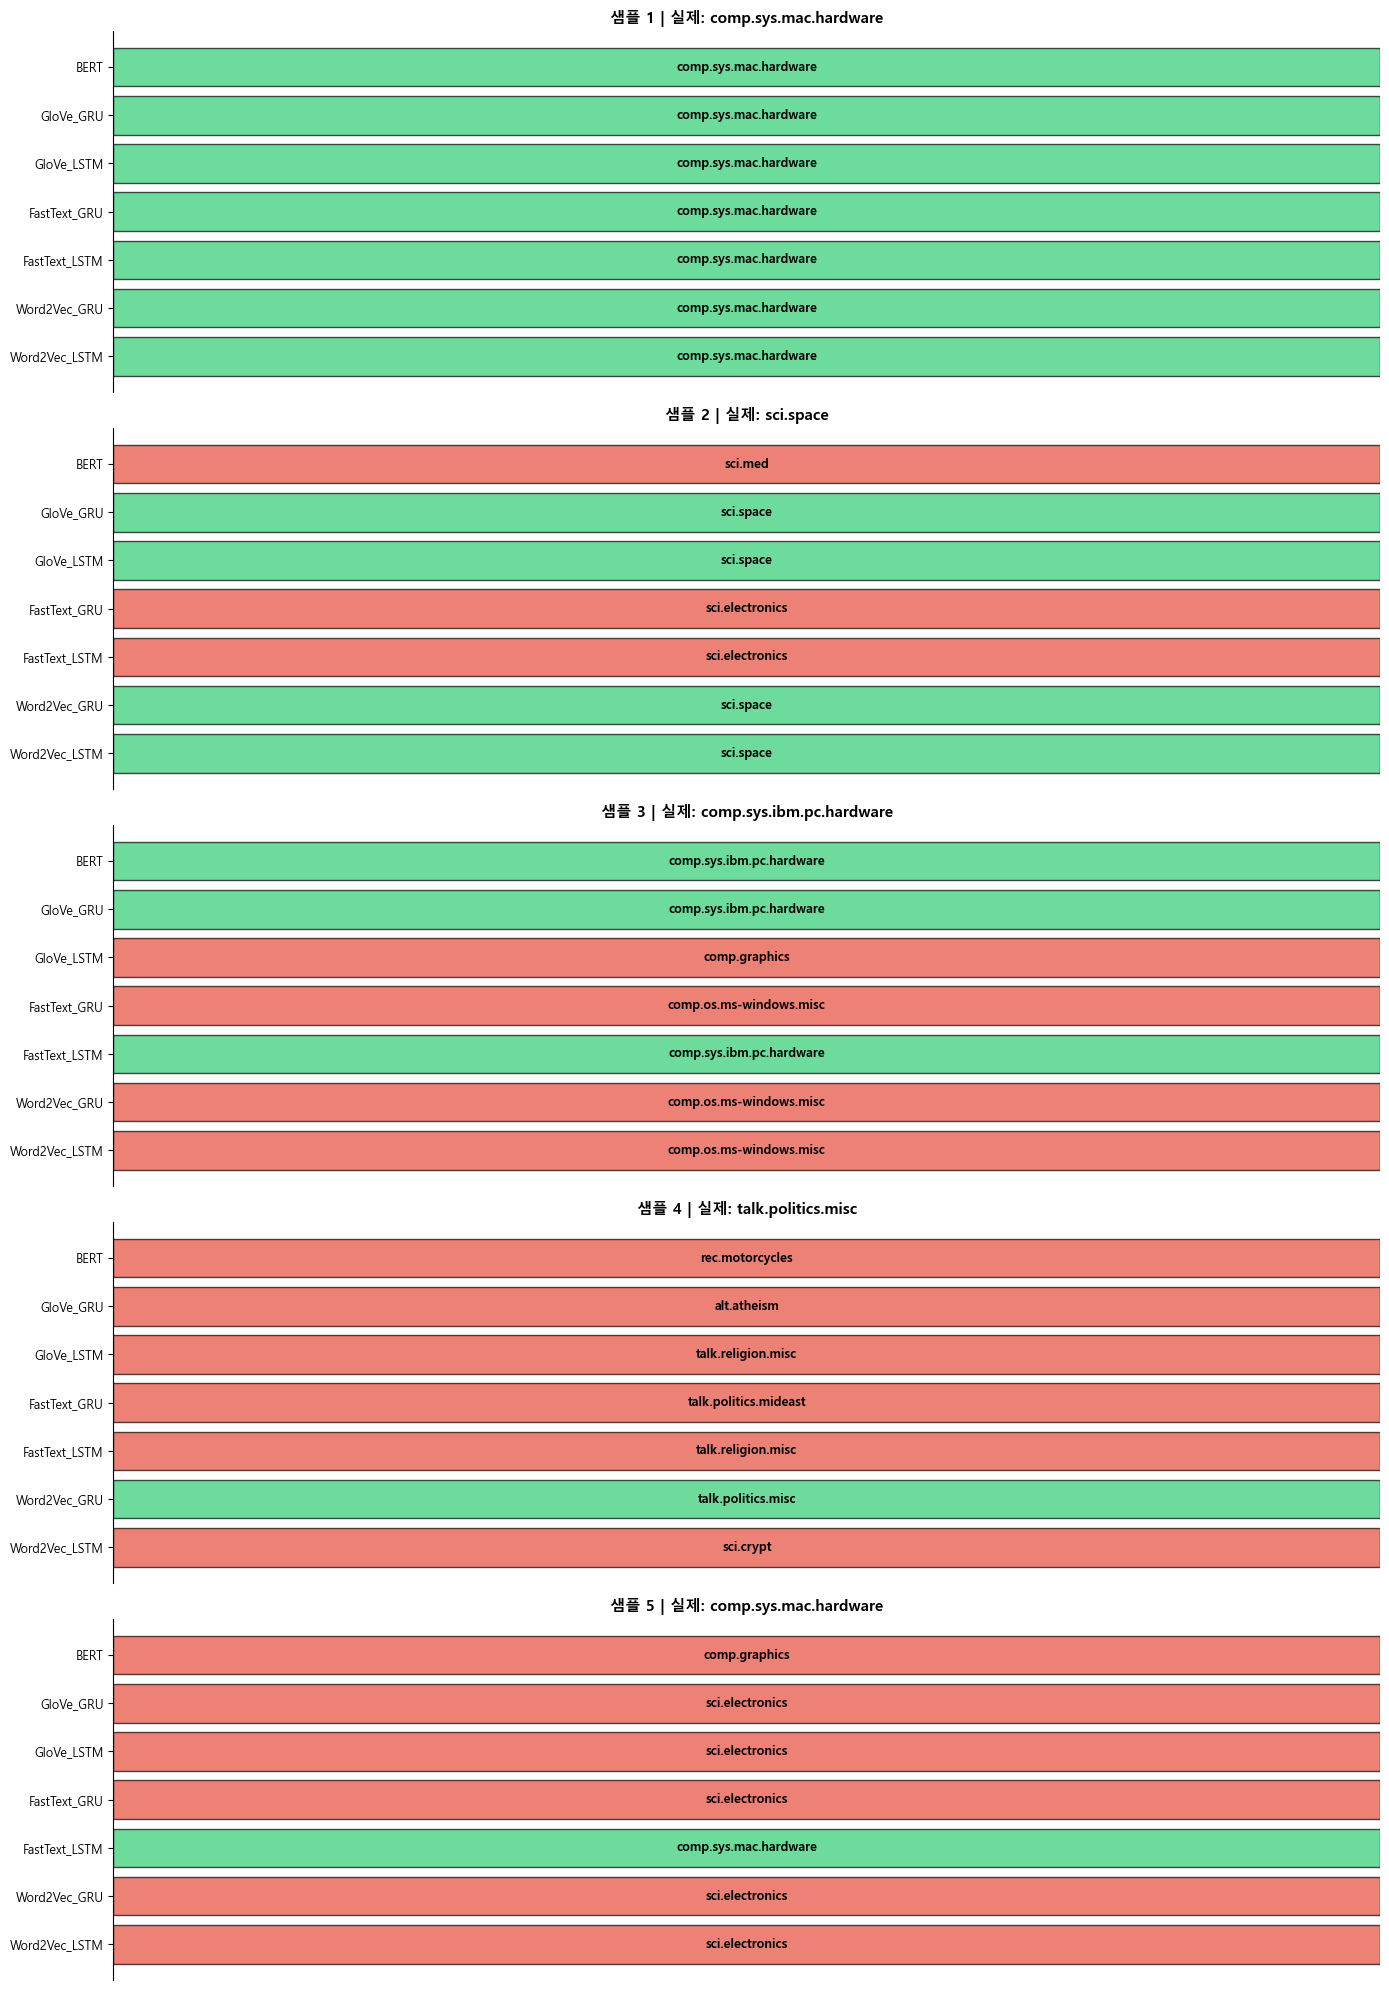

✓ 5개 샘플 예측 분포 시각화 완료


In [87]:
# ========================================================================
# 5. 각 샘플별 예측 분포 시각화
# ========================================================================

print(f"\n{'='*80}")
print("샘플별 예측 분포 시각화")
print(f"{'='*80}\n")

# 처음 5개 샘플만 시각화
num_viz_samples = min(5, len(comparison_results))

fig, axes = plt.subplots(num_viz_samples, 1, figsize=(14, 4*num_viz_samples))
if num_viz_samples == 1:
    axes = [axes]

for idx, result in enumerate(comparison_results[:num_viz_samples]):
    ax = axes[idx]
    
    # 각 모델의 예측
    models = []
    predictions = []
    colors = []
    
    for model_name, pred_label in result['predictions'].items():
        if pred_label == -1:
            continue
        
        models.append(model_name)
        pred_category = test_data.target_names[pred_label]
        predictions.append(pred_category)
        
        # 정답이면 초록색, 오답이면 빨간색
        if pred_label == result['true_label']:
            colors.append('#2ecc71')  # 초록
        else:
            colors.append('#e74c3c')  # 빨강
    
    # 막대 그래프
    y_pos = np.arange(len(models))
    ax.barh(y_pos, [1]*len(models), color=colors, alpha=0.7, edgecolor='black')
    
    # 예측 카테고리 텍스트 표시
    for i, (model, pred) in enumerate(zip(models, predictions)):
        ax.text(0.5, i, pred, ha='center', va='center', 
               fontsize=9, fontweight='bold')
    
    ax.set_yticks(y_pos)
    ax.set_yticklabels(models, fontsize=9)
    ax.set_xlim(0, 1)
    ax.set_xticks([])
    ax.set_title(f'샘플 {idx+1} | 실제: {result["true_category"]}', 
                fontsize=11, fontweight='bold')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(False)

plt.tight_layout()
plt.show()

print(f"✓ {num_viz_samples}개 샘플 예측 분포 시각화 완료")


모델별 예측 확신도 분석



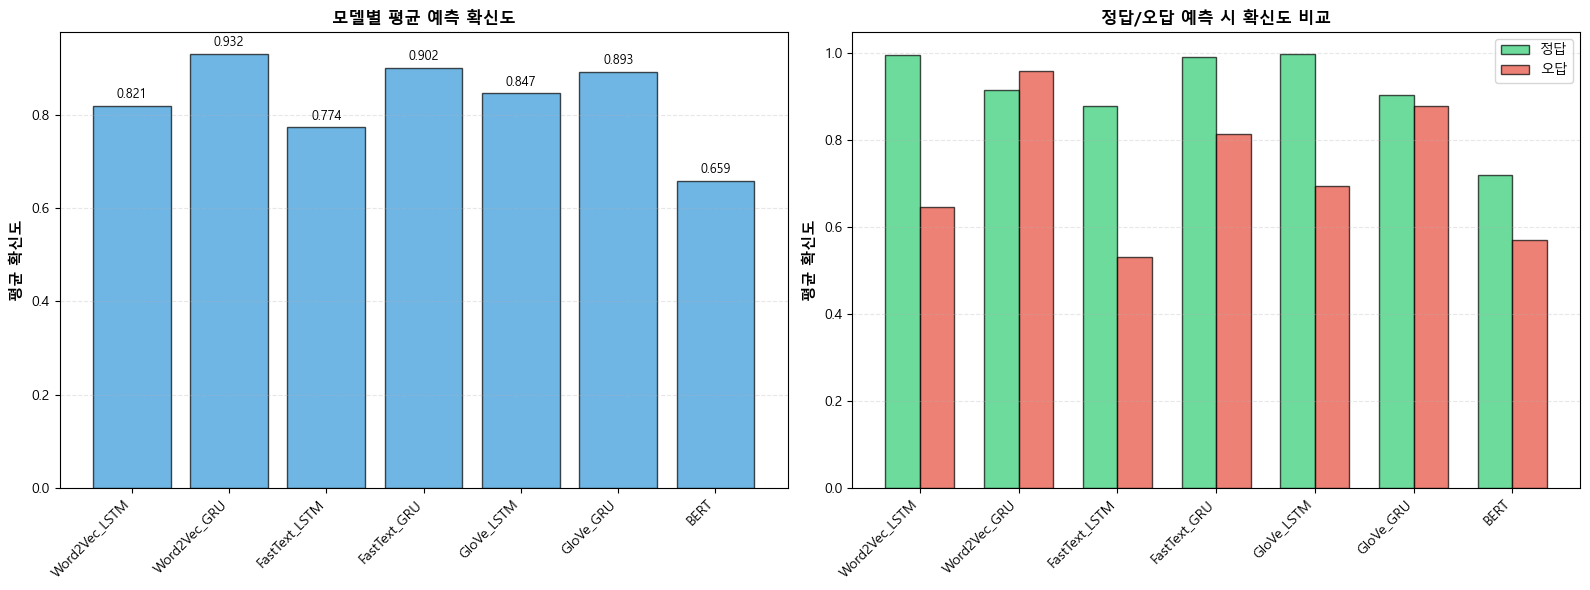

✓ 확신도 분석 완료


In [89]:
# ========================================================================
# 6. 확신도(Confidence) 비교
# ========================================================================

print(f"\n{'='*80}")
print("모델별 예측 확신도 분석")
print(f"{'='*80}\n")

# 각 모델의 평균 확신도
confidence_data = {model: [] for model in all_results.keys()}
correct_confidence = {model: [] for model in all_results.keys()}
incorrect_confidence = {model: [] for model in all_results.keys()}

for result in comparison_results:
    true_label = result['true_label']
    
    for model_name, pred_label in result['predictions'].items():
        if pred_label == -1:
            continue
        
        confidence = result['probabilities'][model_name][pred_label]
        confidence_data[model_name].append(confidence)
        
        if pred_label == true_label:
            correct_confidence[model_name].append(confidence)
        else:
            incorrect_confidence[model_name].append(confidence)

# 시각화
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# 평균 확신도
models = list(all_results.keys())
avg_confidences = [np.mean(confidence_data[m]) if confidence_data[m] else 0 
                   for m in models]

ax1.bar(range(len(models)), avg_confidences, 
       color='#3498db', alpha=0.7, edgecolor='black')
ax1.set_xticks(range(len(models)))
ax1.set_xticklabels(models, rotation=45, ha='right')
ax1.set_ylabel('평균 확신도', fontsize=11, fontweight='bold')
ax1.set_title('모델별 평균 예측 확신도', fontsize=12, fontweight='bold')
ax1.grid(axis='y', alpha=0.3, linestyle='--')

for i, conf in enumerate(avg_confidences):
    ax1.text(i, conf + 0.01, f'{conf:.3f}', 
            ha='center', va='bottom', fontsize=9)

# 정답/오답 확신도 비교
x = np.arange(len(models))
width = 0.35

correct_avg = [np.mean(correct_confidence[m]) if correct_confidence[m] else 0 
               for m in models]
incorrect_avg = [np.mean(incorrect_confidence[m]) if incorrect_confidence[m] else 0 
                 for m in models]

ax2.bar(x - width/2, correct_avg, width, label='정답', 
       color='#2ecc71', alpha=0.7, edgecolor='black')
ax2.bar(x + width/2, incorrect_avg, width, label='오답', 
       color='#e74c3c', alpha=0.7, edgecolor='black')

ax2.set_xticks(x)
ax2.set_xticklabels(models, rotation=45, ha='right')
ax2.set_ylabel('평균 확신도', fontsize=11, fontweight='bold')
ax2.set_title('정답/오답 예측 시 확신도 비교', fontsize=12, fontweight='bold')
ax2.legend()
ax2.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

print("✓ 확신도 분석 완료")

In [90]:
# ========================================================================
# 7. 요약 통계
# ========================================================================

print(f"\n{'='*80}")
print("예측 비교 요약 통계")
print(f"{'='*80}\n")

for model_name in all_results.keys():
    correct = 0
    total = 0
    
    for result in comparison_results:
        pred = result['predictions'].get(model_name, -1)
        if pred != -1:
            if pred == result['true_label']:
                correct += 1
            total += 1
    
    if total > 0:
        accuracy = correct / total * 100
        avg_conf = np.mean(confidence_data[model_name]) if confidence_data[model_name] else 0
        
        print(f"{model_name:<20s} | "
              f"정확도: {accuracy:5.1f}% ({correct}/{total}) | "
              f"평균 확신도: {avg_conf:.4f}")

print(f"\n{'='*80}")
print("✓ 모델 예측 비교 분석 완료")
print(f"{'='*80}")


예측 비교 요약 통계

Word2Vec_LSTM        | 정확도:  50.0% (5/10) | 평균 확신도: 0.8206
Word2Vec_GRU         | 정확도:  60.0% (6/10) | 평균 확신도: 0.9321
FastText_LSTM        | 정확도:  70.0% (7/10) | 평균 확신도: 0.7742
FastText_GRU         | 정확도:  50.0% (5/10) | 평균 확신도: 0.9022
GloVe_LSTM           | 정확도:  50.0% (5/10) | 평균 확신도: 0.8467
GloVe_GRU            | 정확도:  60.0% (6/10) | 평균 확신도: 0.8929
BERT                 | 정확도:  60.0% (6/10) | 평균 확신도: 0.6592

✓ 모델 예측 비교 분석 완료


전체 모델 최종 정리 및 종합 분석

1. 전체 모델 성능 요약

성능 순위:
--------------------------------------------------------------------------------
1. GloVe_GRU            | Acc: 0.7447 | Epochs: 37 | 새 학습
2. FastText_GRU         | Acc: 0.7254 | Epochs: 43 | 새 학습
3. BERT                 | Acc: 0.7252 | Epochs:  3 | ✓
4. GloVe_LSTM           | Acc: 0.7112 | Epochs: 50 | 새 학습
5. Word2Vec_GRU         | Acc: 0.6887 | Epochs: 21 | 새 학습
6. FastText_LSTM        | Acc: 0.6830 | Epochs: 49 | 새 학습
7. Word2Vec_LSTM        | Acc: 0.6625 | Epochs: 50 | 새 학습
--------------------------------------------------------------------------------

★ 최고 성능: GloVe_GRU (0.7447)
★ 최저 성능: Word2Vec_LSTM (0.6625)
★ 성능 차이: 8.22%p


C:\Users\w00sh\AppData\Local\Temp\ipykernel_14508\2206670062.py:159: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax4.boxplot(box_data, labels=box_labels, patch_artist=True,


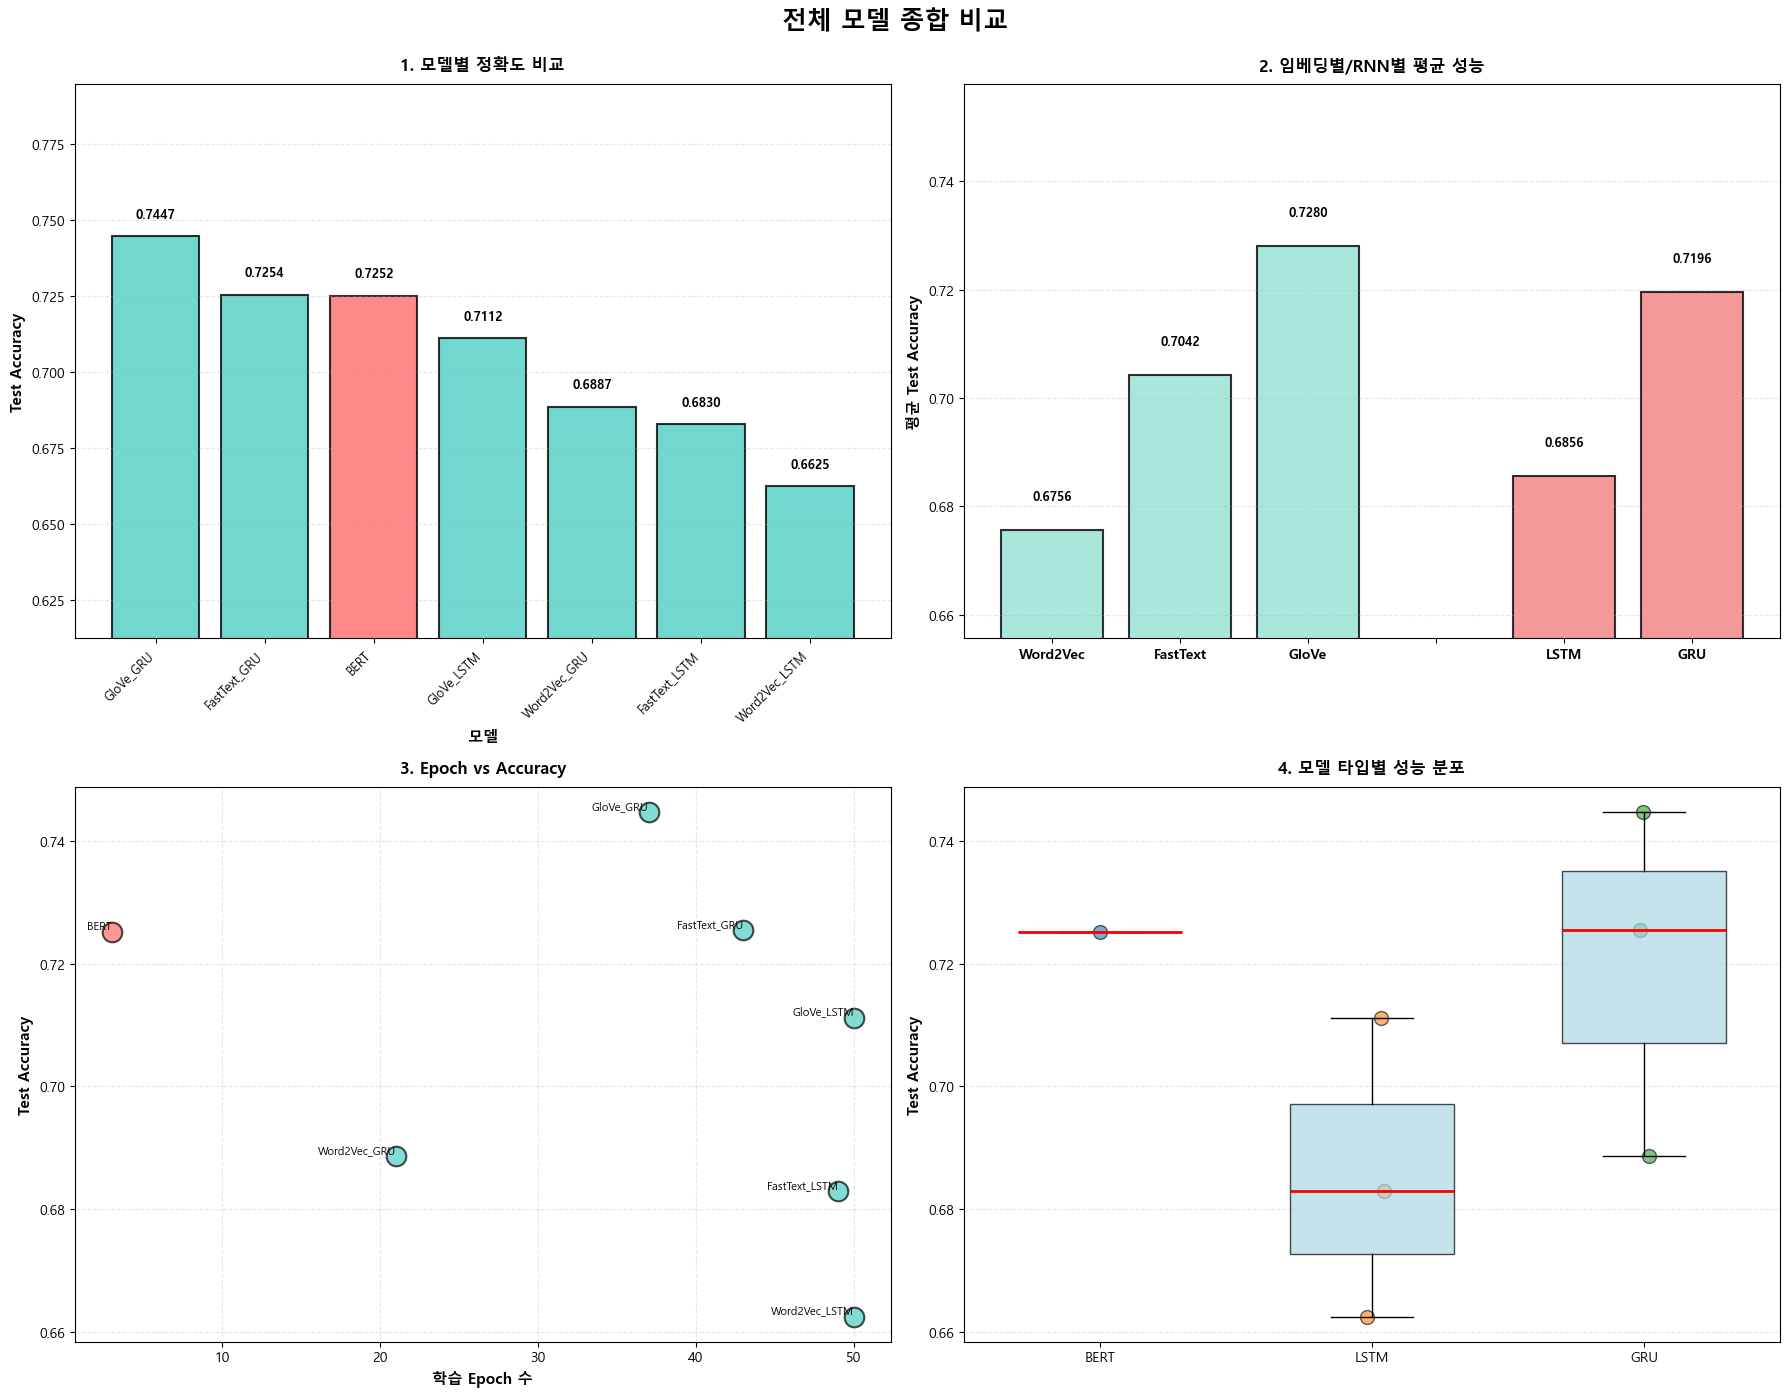


2. 상세 통계

[전체 모델 통계]
  평균 정확도: 0.7058
  표준편차:    0.0267
  최고:        0.7447
  최저:        0.6625
  범위:        0.0822

[임베딩별 순위]
  1. GloVe       : 0.7280
  2. FastText    : 0.7042
  3. Word2Vec    : 0.6756

[RNN 타입별 비교]
  GRU         : 0.7196
  LSTM        : 0.6856

  → GRU가 3.40%p 더 우수

[BERT vs RNN 비교]
  BERT:     0.7252
  RNN 평균: 0.7026
  차이:     2.26%p
  → BERT가 RNN 평균보다 우수

3. 최고 성능 모델 상세 분석: GloVe_GRU

[기본 정보]
  모델명:       GloVe_GRU
  정확도:       0.7447
  학습 Epoch:   37
  저장 경로:    model\GloVe_GRU_best.pth

[분류 리포트]
--------------------------------------------------------------------------------
                          precision    recall  f1-score   support

             alt.atheism     0.7200    0.6771    0.6979       319
           comp.graphics     0.5726    0.6889    0.6254       389
 comp.os.ms-windows.misc     0.7428    0.5863    0.6553       394
comp.sys.ibm.pc.hardware     0.6154    0.6939    0.6523       392
   comp.sys.mac.hardware     0.6128    0.7481    0.6737      

In [91]:
# ============================================================================
# 최종 종합 정리 및 시각화
# ============================================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import classification_report

print("="*80)
print("전체 모델 최종 정리 및 종합 분석")
print("="*80)

# ========== 1. 전체 모델 성능 요약 테이블 ==========
print("\n" + "="*80)
print("1. 전체 모델 성능 요약")
print("="*80)

summary_data = []
for model_name, result in all_results.items():
    summary_data.append({
        '모델': model_name,
        'Test Accuracy': result['test_accuracy'],
        '학습 Epoch': len(result['history']['train_loss']) if result['history']['train_loss'] else 0,
        '체크포인트': '✓' if result.get('loaded_from_checkpoint', False) else '새 학습',
        '저장 경로': result.get('save_path', 'N/A')
    })

summary_df = pd.DataFrame(summary_data)
summary_df = summary_df.sort_values('Test Accuracy', ascending=False)

print("\n성능 순위:")
print("-"*80)
for idx, row in summary_df.iterrows():
    print(f"{summary_df.index.tolist().index(idx)+1}. {row['모델']:20s} | "
          f"Acc: {row['Test Accuracy']:.4f} | "
          f"Epochs: {row['학습 Epoch']:2d} | "
          f"{row['체크포인트']}")
print("-"*80)

best_model = summary_df.iloc[0]['모델']
best_acc = summary_df.iloc[0]['Test Accuracy']
worst_model = summary_df.iloc[-1]['모델']
worst_acc = summary_df.iloc[-1]['Test Accuracy']

print(f"\n★ 최고 성능: {best_model} ({best_acc:.4f})")
print(f"★ 최저 성능: {worst_model} ({worst_acc:.4f})")
print(f"★ 성능 차이: {(best_acc - worst_acc)*100:.2f}%p")


# ========== 2. 종합 비교 시각화 (2x2 레이아웃) ==========
fig = plt.figure(figsize=(18, 14))
fig.suptitle('전체 모델 종합 비교', fontsize=18, fontweight='bold', y=0.995)

# 2-1. 정확도 막대 그래프
ax1 = plt.subplot(2, 2, 1)
models = summary_df['모델'].values
accs = summary_df['Test Accuracy'].values
colors = ['#FF6B6B' if 'BERT' in m else '#4ECDC4' for m in models]

bars = ax1.bar(range(len(models)), accs, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)
for i, (m, a) in enumerate(zip(models, accs)):
    ax1.text(i, a + 0.005, f'{a:.4f}', ha='center', va='bottom', 
             fontsize=9, fontweight='bold')

ax1.set_xlabel('모델', fontsize=11, fontweight='bold')
ax1.set_ylabel('Test Accuracy', fontsize=11, fontweight='bold')
ax1.set_title('1. 모델별 정확도 비교', fontsize=12, fontweight='bold', pad=10)
ax1.set_xticks(range(len(models)))
ax1.set_xticklabels(models, rotation=45, ha='right', fontsize=9)
ax1.set_ylim([min(accs) - 0.05, max(accs) + 0.05])
ax1.grid(axis='y', alpha=0.3, linestyle='--')

# 2-2. 임베딩별/RNN별 평균 (BERT 제외)
ax2 = plt.subplot(2, 2, 2)
rnn_results = {k: v for k, v in all_results.items() if 'BERT' not in k}

if len(rnn_results) >= 6:
    # 임베딩별 평균
    emb_avg = {}
    for emb in ['Word2Vec', 'FastText', 'GloVe']:
        accs_list = [rnn_results[f"{emb}_{rnn}"]['test_accuracy']
                     for rnn in ['LSTM', 'GRU'] if f"{emb}_{rnn}" in rnn_results]
        if accs_list:
            emb_avg[emb] = np.mean(accs_list)
    
    # RNN별 평균
    rnn_avg = {}
    for rnn in ['LSTM', 'GRU']:
        accs_list = [rnn_results[f"{emb}_{rnn}"]['test_accuracy']
                     for emb in ['Word2Vec', 'FastText', 'GloVe'] if f"{emb}_{rnn}" in rnn_results]
        if accs_list:
            rnn_avg[rnn] = np.mean(accs_list)
    
    # 임베딩 + RNN 함께 표시
    x_pos = np.arange(len(emb_avg) + len(rnn_avg) + 1)
    heights = list(emb_avg.values()) + [0] + list(rnn_avg.values())
    labels = list(emb_avg.keys()) + [''] + list(rnn_avg.keys())
    colors_bar = ['#95E1D3']*3 + ['white'] + ['#F38181']*2
    
    bars = ax2.bar(x_pos, heights, color=colors_bar, alpha=0.8, edgecolor='black', linewidth=1.5)
    
    for i, (h, l) in enumerate(zip(heights, labels)):
        if l:  # 빈 칸 제외
            ax2.text(i, h + 0.005, f'{h:.4f}', ha='center', va='bottom', 
                    fontsize=9, fontweight='bold')
    
    ax2.set_ylabel('평균 Test Accuracy', fontsize=11, fontweight='bold')
    ax2.set_title('2. 임베딩별/RNN별 평균 성능', fontsize=12, fontweight='bold', pad=10)
    ax2.set_xticks(x_pos)
    ax2.set_xticklabels(labels, fontsize=10, fontweight='bold')
    ax2.set_ylim([min([h for h in heights if h > 0]) - 0.02, max(heights) + 0.03])
    ax2.grid(axis='y', alpha=0.3, linestyle='--')
else:
    ax2.text(0.5, 0.5, 'RNN 모델 데이터 부족', ha='center', va='center', 
            fontsize=12, transform=ax2.transAxes)
    ax2.set_title('2. 임베딩별/RNN별 평균 성능', fontsize=12, fontweight='bold', pad=10)

# 2-3. Epoch별 최종 정확도 분포
ax3 = plt.subplot(2, 2, 3)
epochs_list = [len(r['history']['train_loss']) if r['history']['train_loss'] else 0 
               for r in all_results.values()]
accs_list = [r['test_accuracy'] for r in all_results.values()]
model_names = list(all_results.keys())

scatter_colors = ['#FF6B6B' if 'BERT' in m else '#4ECDC4' for m in model_names]

for i, (e, a, m, c) in enumerate(zip(epochs_list, accs_list, model_names, scatter_colors)):
    ax3.scatter(e, a, s=200, c=c, alpha=0.7, edgecolor='black', linewidth=1.5)
    ax3.annotate(m, (e, a), fontsize=8, ha='right', va='bottom')

ax3.set_xlabel('학습 Epoch 수', fontsize=11, fontweight='bold')
ax3.set_ylabel('Test Accuracy', fontsize=11, fontweight='bold')
ax3.set_title('3. Epoch vs Accuracy', fontsize=12, fontweight='bold', pad=10)
ax3.grid(True, alpha=0.3, linestyle='--')

# 2-4. 모델 타입별 박스플롯
ax4 = plt.subplot(2, 2, 4)

# 모델 그룹화
bert_acc = [all_results['BERT']['test_accuracy']] if 'BERT' in all_results else []
lstm_accs = [v['test_accuracy'] for k, v in all_results.items() if 'LSTM' in k]
gru_accs = [v['test_accuracy'] for k, v in all_results.items() if 'GRU' in k]

box_data = []
box_labels = []

if bert_acc:
    box_data.append(bert_acc)
    box_labels.append('BERT')
if lstm_accs:
    box_data.append(lstm_accs)
    box_labels.append('LSTM')
if gru_accs:
    box_data.append(gru_accs)
    box_labels.append('GRU')

bp = ax4.boxplot(box_data, labels=box_labels, patch_artist=True,
                 boxprops=dict(facecolor='lightblue', alpha=0.7),
                 medianprops=dict(color='red', linewidth=2),
                 widths=0.6)

# 개별 점 표시
for i, data in enumerate(box_data):
    y = data
    x = np.random.normal(i+1, 0.04, size=len(y))
    ax4.scatter(x, y, alpha=0.6, s=100, edgecolor='black', linewidth=1)

ax4.set_ylabel('Test Accuracy', fontsize=11, fontweight='bold')
ax4.set_title('4. 모델 타입별 성능 분포', fontsize=12, fontweight='bold', pad=10)
ax4.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()


# ========== 3. 상세 통계 ==========
print("\n" + "="*80)
print("2. 상세 통계")
print("="*80)

print("\n[전체 모델 통계]")
all_accs = [r['test_accuracy'] for r in all_results.values()]
print(f"  평균 정확도: {np.mean(all_accs):.4f}")
print(f"  표준편차:    {np.std(all_accs):.4f}")
print(f"  최고:        {np.max(all_accs):.4f}")
print(f"  최저:        {np.min(all_accs):.4f}")
print(f"  범위:        {np.max(all_accs) - np.min(all_accs):.4f}")

if len(rnn_results) >= 6 and emb_avg and rnn_avg:
    print("\n[임베딩별 순위]")
    sorted_emb = sorted(emb_avg.items(), key=lambda x: x[1], reverse=True)
    for i, (emb, acc) in enumerate(sorted_emb, 1):
        print(f"  {i}. {emb:12s}: {acc:.4f}")
    
    print("\n[RNN 타입별 비교]")
    for rnn, acc in sorted(rnn_avg.items(), key=lambda x: x[1], reverse=True):
        print(f"  {rnn:12s}: {acc:.4f}")
    
    if 'LSTM' in rnn_avg and 'GRU' in rnn_avg:
        diff = rnn_avg['LSTM'] - rnn_avg['GRU']
        better = 'LSTM' if diff > 0 else 'GRU'
        print(f"\n  → {better}가 {abs(diff)*100:.2f}%p 더 우수")

if 'BERT' in all_results:
    bert_acc = all_results['BERT']['test_accuracy']
    rnn_avg_acc = np.mean([v['test_accuracy'] for k, v in all_results.items() if 'BERT' not in k])
    print(f"\n[BERT vs RNN 비교]")
    print(f"  BERT:     {bert_acc:.4f}")
    print(f"  RNN 평균: {rnn_avg_acc:.4f}")
    print(f"  차이:     {(bert_acc - rnn_avg_acc)*100:.2f}%p")
    if bert_acc > rnn_avg_acc:
        print(f"  → BERT가 RNN 평균보다 우수")
    else:
        print(f"  → RNN 평균이 BERT보다 우수")


# ========== 4. 최고 성능 모델 상세 리포트 ==========
print("\n" + "="*80)
print(f"3. 최고 성능 모델 상세 분석: {best_model}")
print("="*80)

best_result = all_results[best_model]

print(f"\n[기본 정보]")
print(f"  모델명:       {best_model}")
print(f"  정확도:       {best_result['test_accuracy']:.4f}")
print(f"  학습 Epoch:   {len(best_result['history']['train_loss']) if best_result['history']['train_loss'] else 0}")
print(f"  저장 경로:    {best_result.get('save_path', 'N/A')}")

if 'predictions' in best_result and 'labels' in best_result:
    if best_result['predictions'] and best_result['labels']:
        print(f"\n[분류 리포트]")
        print("-"*80)
        try:
            report = classification_report(
                best_result['labels'],
                best_result['predictions'],
                target_names=train_data.target_names,
                digits=4
            )
            print(report)
        except Exception as e:
            print(f"  분류 리포트 생성 실패: {e}")


# ========== 5. 저장된 파일 확인 ==========
print("\n" + "="*80)
print("4. 저장된 모델 파일")
print("="*80)

import os
model_dir = 'model'

if os.path.exists(model_dir):
    files = sorted([f for f in os.listdir(model_dir) if f.endswith('.pth')])
    
    print(f"\n저장 위치: {os.path.abspath(model_dir)}")
    print(f"파일 개수: {len(files)}개\n")
    
    total_size = 0
    for i, f in enumerate(files, 1):
        file_path = os.path.join(model_dir, f)
        size_mb = os.path.getsize(file_path) / (1024 * 1024)
        total_size += size_mb
        print(f"{i}. {f:30s} ({size_mb:6.2f} MB)")
    
    print(f"\n전체 크기: {total_size:.2f} MB")
else:
    print(f"\n'{model_dir}' 폴더가 없습니다.")


# ========== 6. 실험 요약 ==========
print("\n" + "="*80)
print("5. 실험 요약")
print("="*80)

print(f"""
실험 개요:
  - 총 모델 수:     {len(all_results)}개
  - 데이터셋:       20 Newsgroups
  - 클래스 수:      20개
  - 평가 지표:      Accuracy
  
모델 구성:
  - 임베딩 방법:    Word2Vec, FastText, GloVe
  - RNN 구조:       LSTM, GRU
  - Transformer:    BERT
  
주요 결과:
  ★ 최고 성능:      {best_model} ({best_acc:.4f})
  ★ 평균 성능:      {np.mean(all_accs):.4f}
  ★ 성능 범위:      {np.min(all_accs):.4f} ~ {np.max(all_accs):.4f}
""")


# ========== 7. 결론 ==========
print("="*80)
print("6. 결론")
print("="*80)

# 자동 결론 생성
if 'BERT' in all_results:
    bert_acc = all_results['BERT']['test_accuracy']
    rnn_accs = [v['test_accuracy'] for k, v in all_results.items() if 'BERT' not in k]
    
    if bert_acc == max(all_accs):
        print("\n✓ BERT 모델이 가장 높은 성능을 보였습니다.")
    
    if bert_acc > np.mean(rnn_accs):
        print(f"✓ BERT가 RNN 평균보다 {(bert_acc - np.mean(rnn_accs))*100:.2f}%p 높은 성능을 기록했습니다.")

if len(rnn_results) >= 6 and emb_avg:
    best_emb = max(emb_avg, key=emb_avg.get)
    print(f"✓ 임베딩 방법 중에서는 {best_emb}가 가장 우수했습니다.")

if len(rnn_results) >= 6 and rnn_avg:
    best_rnn = max(rnn_avg, key=rnn_avg.get)
    print(f"✓ RNN 구조 중에서는 {best_rnn}가 더 나은 성능을 보였습니다.")

loaded_count = sum(1 for r in all_results.values() if r.get('loaded_from_checkpoint', False))
if loaded_count > 0:
    print(f"\n✓ {loaded_count}개 모델이 저장된 체크포인트에서 로드되었습니다.")

print("\n" + "="*80)
print("✓ 전체 분석 완료!")
print("="*80)

#### 프로젝트 회고

#### 실험 개요 및 진행 과정

본 프로젝트에서는 20 Newsgroups 데이터셋을 활용하여 총 7개의 딥러닝 모델(RNN 기반 6개, BERT 1개)을 구현하고 성능을 비교 분석하였습니다. Word2Vec, FastText, GloVe 세 가지 임베딩 방법과 LSTM, GRU 두 가지 RNN 구조를 조합하여 실험을 진행했으며, 최종적으로 GloVe_GRU 모델이 74.47%의 정확도로 가장 우수한 성능을 기록했습니다.

실험 과정에서 각 임베딩 방법의 특성을 이해하고, RNN 레이어 구조를 직접 구현하면서 LSTM과 GRU의 메커니즘을 깊이 있게 학습할 수 있었습니다. 특히 GRU가 LSTM에 비해 파라미터 수가 적으면서도 평균 3.40%p 높은 성능을 보인 점이 인상적이었습니다.

#### 주요 발견 사항

BERT 모델의 경우 단 3 epoch만에 RNN 최고 성능 모델과 유사한 수준에 도달하여, 사전 학습된 언어 모델의 효과를 확인할 수 있었습니다. 이는 전이 학습(Transfer Learning)의 강력함을 보여주는 결과였습니다.

그러나 BERT의 학습 시간은 10 epoch에 약 800분이 소요되어 실용성 측면에서 과제가 있음을 확인했습니다. 이는 RNN 모델 대비 약 5-10배 긴 시간으로, 리소스가 제한적인 환경에서는 경량 모델의 효용성이 더 높을 수 있다는 점을 시사합니다.

샘플별 예측 분석을 통해 모델들이 명확한 기술 용어가 포함된 샘플(comp.windows.x, sci.crypt 등)에서는 85% 이상의 높은 일치도를 보인 반면, 카테고리 경계가 모호한 추상적 주제(talk.politics.misc, talk.religion.misc)에서는 F1 점수가 0.45-0.59로 낮게 나타났습니다.

#### 기술적 개선 방향

학습 효율성 개선을 위해 Mixed Precision Training(FP16)을 도입할 계획입니다. 관련 문헌에 따르면 이를 통해 학습 속도를 약 2배 향상시킬 수 있으며, 메모리 사용량도 감소시킬 수 있다고 합니다.

또한 앙상블 방법론을 적용하여 GloVe_GRU와 BERT의 장점을 결합하는 방안을 고려하고 있습니다. 이를 통해 기술 용어 분류에 강한 RNN 모델과 문맥 이해에 뛰어nan BERT의 상호 보완이 가능할 것으로 예상됩니다.

#### 학습 성과 및 결론

본 프로젝트를 통해 임베딩 방법의 선택이 최종 성능에 미치는 영향(GloVe가 Word2Vec 대비 5.24%p 우수)을 정량적으로 확인할 수 있었습니다. 또한 RNN 아키텍처를 직접 구현하고 비교하면서 각 구조의 장단점을 실질적으로 이해하게 되었습니다.

특히 "최신 모델이 항상 최선의 선택은 아니다"라는 점을 체감했습니다. 작업의 특성과 가용 리소스에 따라 경량 RNN 모델이 더 적합할 수 있으며, 임베딩 선택과 하이퍼파라미터 튜닝이 모델 아키텍처 선택만큼 중요하다는 것을 확인했습니다.

경량화 모델 사용하는 방식으로 진행하면 어떨까 합니다.

DistilBERT: BERT 대비 40% 빠르고, 60% 작으며, 성능은 97% 유지
ALBERT: 파라미터 공유로 모델 크기 대폭 감소
TinyBERT: 지식 증류(Knowledge Distillation)로 추가 경량화

다양한 모델을 비교할 수 있어서 즐거운 시간이였습니다.